In [9]:
github_raw_url1 = 'https://raw.githubusercontent.com/lauradiosan/AI-UBB/refs/heads/main/2025-2026/labs/lab05/data/v1_world-happiness-report-2017.csv'
github_raw_url2 = 'https://raw.githubusercontent.com/lauradiosan/AI-UBB/refs/heads/main/2025-2026/labs/lab05/data/v2_world-happiness-report-2017.csv'
github_raw_url3 = 'https://raw.githubusercontent.com/lauradiosan/AI-UBB/refs/heads/main/2025-2026/labs/lab05/data/v3_world-happiness-report-2017.csv'


# PROBLEMA 1 - pentru caracteristica Family


In [14]:
import csv
import os
import matplotlib.pyplot as plt
import numpy as np
from sklearn import linear_model
import urllib.request

In [5]:
def loadDataFromGitHubFamily1(github_raw_url, inputVariableName, outputVariableName):
    # Descarcă fișierul de pe GitHub
    response = urllib.request.urlopen(github_raw_url)
    lines = [line.decode('utf-8') for line in response.readlines()]

    data = [] # valorile efective
    dataNames = [] # numele coloanelor din prima linie a csv-ului
    csv_reader = csv.reader(lines, delimiter=',') # citeste continutul fisierului
    for i, row in enumerate(csv_reader):
        if i == 0:
            dataNames = row
        else:
            data.append(row)

    selectedVariable = dataNames.index(inputVariableName)
    inputs = [float(data[i][selectedVariable]) for i in range(len(data))] # ia datele din coloana cautata si transforma si valorile in float
    selectedOutput = dataNames.index(outputVariableName) # la fel pentru valorile de output
    outputs = [float(data[i][selectedOutput]) for i in range(len(data))]

    return inputs, outputs

In [6]:
inputs1, outputs1 = loadDataFromGitHubFamily1(github_raw_url1, 'Family', 'Happiness.Score') # input - caracteristicile pe baza carora modelul invata
inputs2, outputs2 = loadDataFromGitHubFamily1(github_raw_url2, 'Family', 'Happiness.Score') # output - valorile pe care vrem sa le prezicem
inputs3, outputs3 = loadDataFromGitHubFamily1(github_raw_url3, 'Family', 'Happiness.Score')

Fis


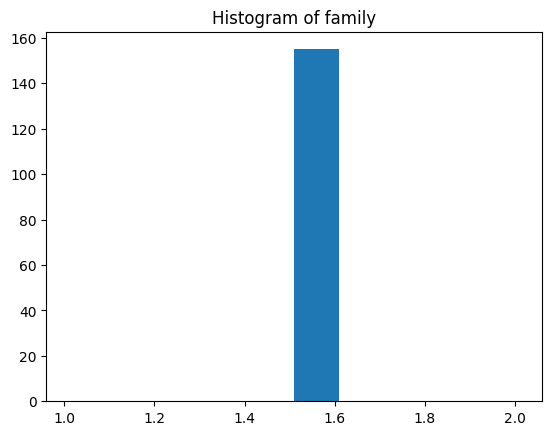

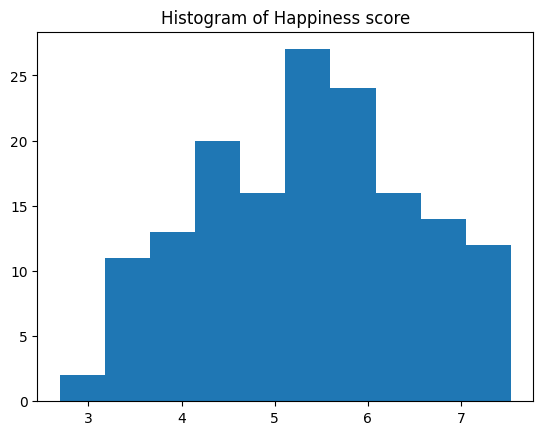

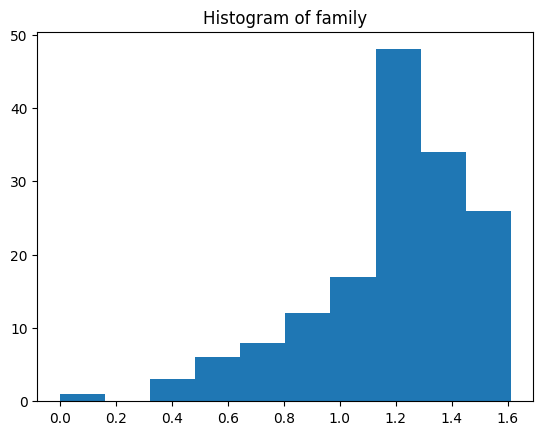

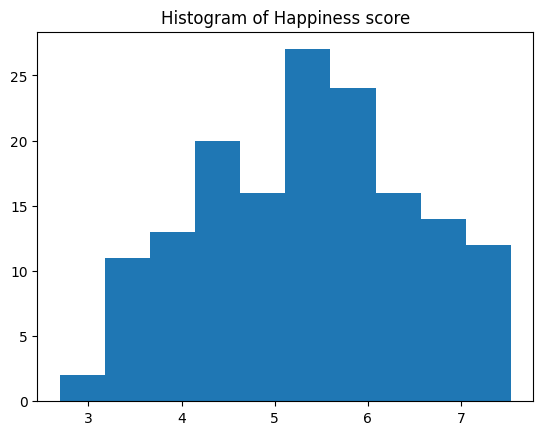

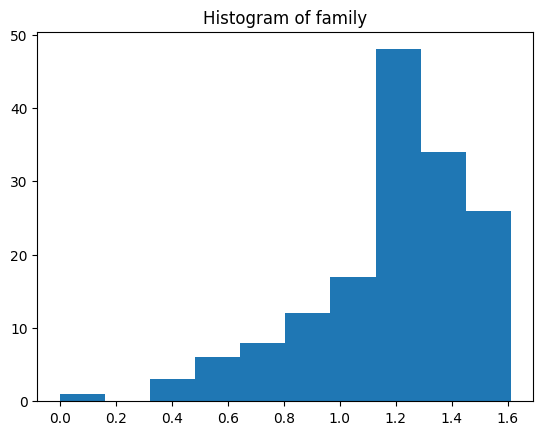

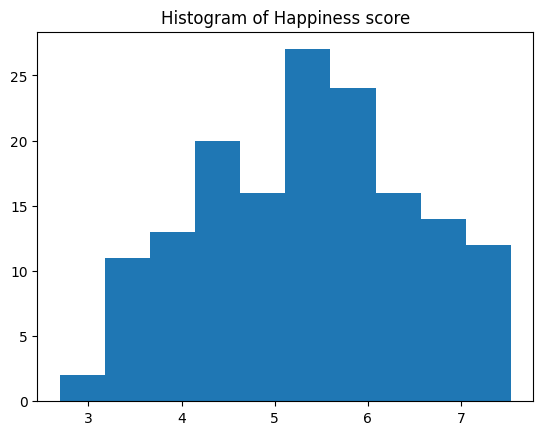

In [7]:
# Histograme pentru a vedea cum sunt distribuite valorile

def plotDataHistogramFamily1(x, variableName):
    n, bins, patches = plt.hist(x, 10)
    plt.title('Histogram of ' + variableName)
    plt.show()

print("Fis")
plotDataHistogramFamily1(inputs1, 'family')
plotDataHistogramFamily1(outputs1, 'Happiness score')


plotDataHistogramFamily1(inputs2, 'family')
plotDataHistogramFamily1(outputs2, 'Happiness score')

plotDataHistogramFamily1(inputs3, 'family')
plotDataHistogramFamily1(outputs3, 'Happiness score')

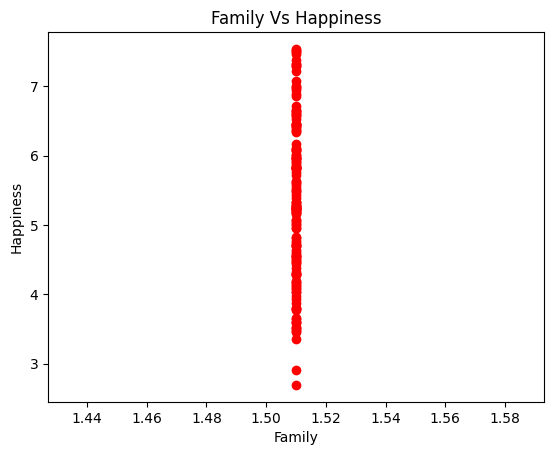

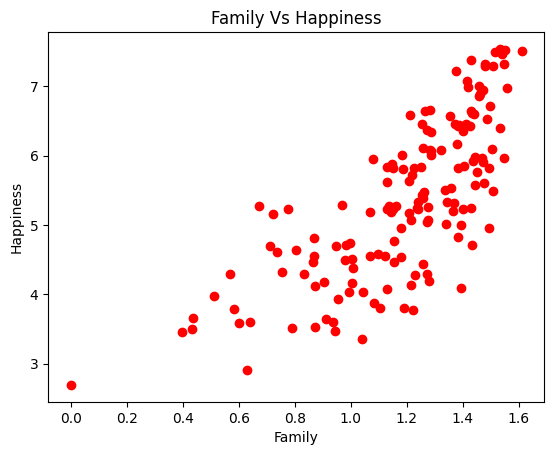

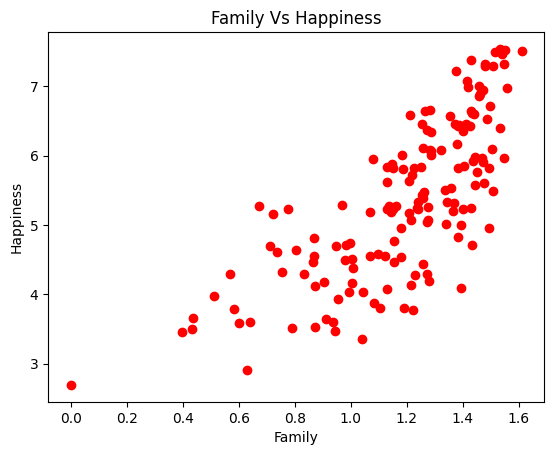

In [8]:
def verifica_liniaritatea(inputs, outputs):
  # Functia ne ajuta sa verificam daca putem sa folosim regresie liniara, adica o functie de genul f(x) = w0 + w1*x
  plt.plot(inputs, outputs, 'ro')
  plt.xlabel('Family')
  plt.ylabel('Happiness')
  plt.title('Family Vs Happiness')
  plt.show()

verifica_liniaritatea(inputs1, outputs1)
verifica_liniaritatea(inputs2, outputs2)
verifica_liniaritatea(inputs3, outputs3)

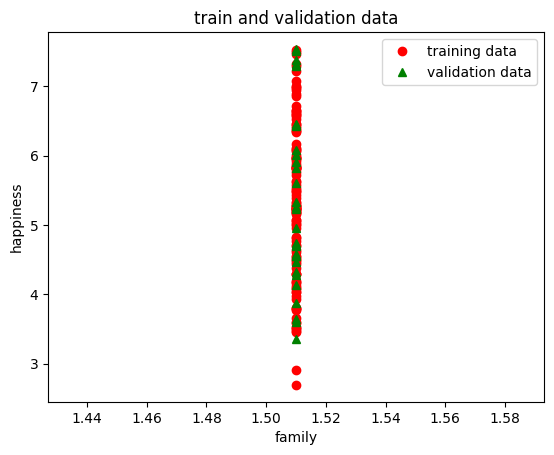

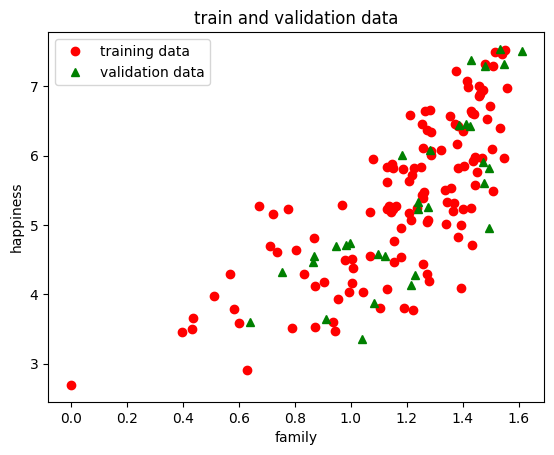

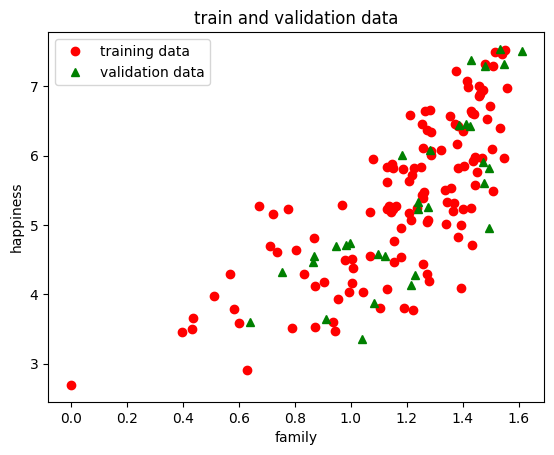

In [9]:
# Urmeaza sa impartim datele in doua, o parte dintre ele(mai exact 80%) vor fi date pentru antranarea modelului, iar restul de 20% vor fi date pentru testare

def data_split_family_1(inputs, outputs):
  np.random.seed(5) # fixarea random-ului, pentru a avea aceleasi rezultate la fiecare rulare
  indexes = [i for i in range(len(inputs))]
  trainSample = np.random.choice(indexes, int(0.8 * len(inputs)), replace = False) # se aleg random 80% din date
  validationSample = [i for i in indexes  if not i in trainSample]

  trainInputs = [inputs[i] for i in trainSample] # se extrag valorile
  trainOutputs = [outputs[i] for i in trainSample]

  validationInputs = [inputs[i] for i in validationSample]
  validationOutputs = [outputs[i] for i in validationSample]

  # Reprezentam valorile pentru a vedea daca sunt dispuse proportional
  plt.plot(trainInputs, trainOutputs, 'ro', label = 'training data')
  plt.plot(validationInputs, validationOutputs, 'g^', label = 'validation data')
  plt.title('train and validation data')
  plt.xlabel('family')
  plt.ylabel('happiness')
  plt.legend()
  plt.show()

  return trainInputs, trainOutputs, validationInputs, validationOutputs

trainInputs1, trainOutputs1, validationInputs1, validationOutputs1 = data_split_family_1(inputs1, outputs1)
trainInputs2, trainOutputs2, validationInputs2, validationOutputs2 = data_split_family_1(inputs2, outputs2)
trainInputs3, trainOutputs3, validationInputs3, validationOutputs3 = data_split_family_1(inputs3, outputs3)


In [10]:
def antrenare_model_cu_tool(trainInputs, trainOutputs):
  xx = [[el] for el in trainInputs] # pentru algoritmul din sklearn avea nevoie de un vector de vectori

  regressor = linear_model.LinearRegression() # crearea modelului

  regressor.fit(xx, trainOutputs) # in regresor se pastreaza valorile pentru functie dar avem si posibilitatea de testare tot prin intermediul lui

  w0, w1 = regressor.intercept_, regressor.coef_[0]
  print('Functia identificata: f(x) = ', w0, ' + ', w1, ' * x')

  return regressor, w0, w1


In [11]:
regressor1, w01, w11 = antrenare_model_cu_tool(inputs1, outputs1)
regressor2, w02, w12 = antrenare_model_cu_tool(inputs2, outputs2)
regressor3, w03, w13 = antrenare_model_cu_tool(inputs3, outputs3)

Functia identificata: f(x) =  10.448177865634442  +  -3.373521181390495  * x
Functia identificata: f(x) =  1.8298321525673122  +  2.9642475156757095  * x
Functia identificata: f(x) =  1.8298321525673122  +  2.9642475156757095  * x


In [20]:
# Acum ca am identificat functia de regresie, putem sa o reprezentam ca o linie pe graficul nostru
# Facand aceasta reprezentare vom vedea daca linia intersecteaza cat mai multe puncte sau nu

def reprezentare_regresie(regressor, w0, w1, trainInputs, trainOutputs):
  noOfPoints = 1000
  xref = []
  val = min(trainInputs)
  step = (max(trainInputs) - min(trainInputs)) / noOfPoints
  for i in range(1, noOfPoints):
      xref.append(val)
      val += step
  yref = [w0 + w1 * el for el in xref]

  plt.plot(trainInputs, trainOutputs, 'ro', alpha=0.2, label = 'training data')
  plt.plot(xref, yref, 'b-', label = 'learnt model')
  plt.title('Train data and the learnt model')
  plt.xlabel('Family')
  plt.ylabel('Happiness')
  plt.legend()
  plt.show()

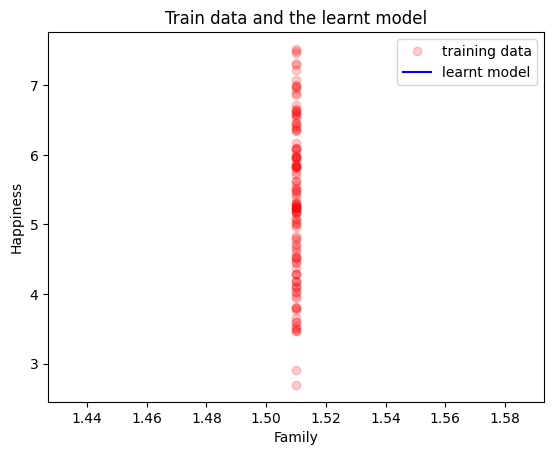

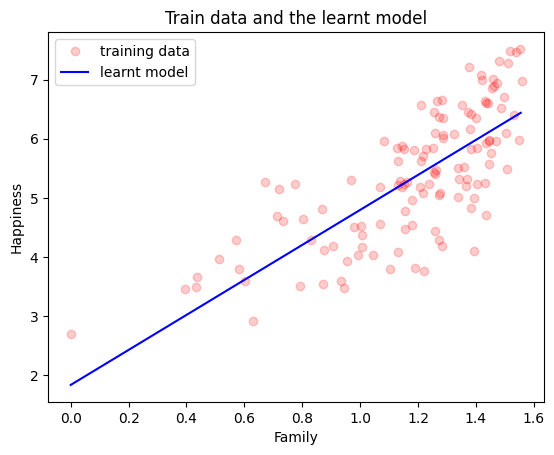

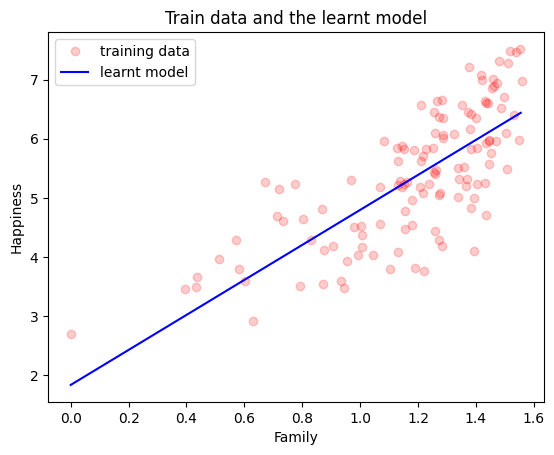

In [21]:
reprezentare_regresie(regressor1, w01, w11, trainInputs1, trainOutputs1)
reprezentare_regresie(regressor2, w02, w12, trainInputs2, trainOutputs2)
reprezentare_regresie(regressor3, w03, w13, trainInputs3, trainOutputs3)

In [18]:
# Folosim modelul pentru a face noi predictii pe care le vom testa mai tarziu

def predictii(regressor, validationInputs, validationOutputs):
  computedValidationOutputs = regressor.predict([[x] for x in validationInputs])

  plt.plot(validationInputs, computedValidationOutputs, 'yo', label = 'computed test data')
  plt.plot(validationInputs, validationOutputs, 'g^', label = 'real test data')
  plt.title('Computed validation and real validation data')
  plt.xlabel('Family')
  plt.ylabel('Happiness')
  plt.legend()
  plt.show()

  return computedValidationOutputs

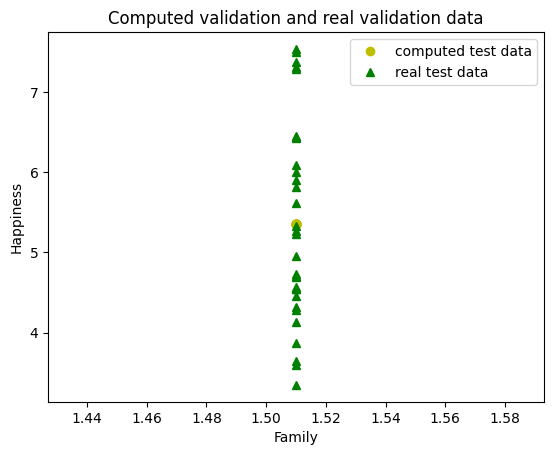

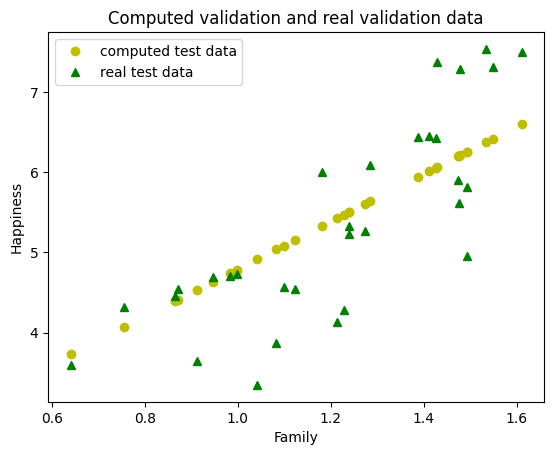

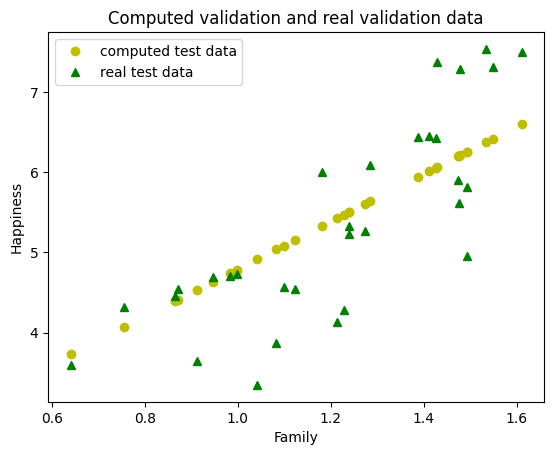

In [19]:
computedValidationOutputs1 = predictii(regressor1, validationInputs1, validationOutputs1)
computedValidationOutputs2 = predictii(regressor2, validationInputs2, validationOutputs2)
computedValidationOutputs3 = predictii(regressor3, validationInputs3, validationOutputs3)

In [27]:
from sklearn.metrics import mean_squared_error, mean_absolute_error

# Vom evalua calitate modelului folosind doua metrici de distanta
# MAE(Mean Squared Error) -- trateaza erorile la fel
# MSE(Mean Squared Error) -- pesepseste mai mult erorile mari
def evaluarea_modelului(validationOutputs, computedValidationOutputs):
    n = len(validationOutputs)

    mse_manual = 0.0
    for real, pred in zip(validationOutputs, computedValidationOutputs):
        mse_manual += (real - pred) ** 2
    mse_manual = mse_manual / n

    mae_manual = 0.0
    for real, pred in zip(validationOutputs, computedValidationOutputs):
        mae_manual += abs(real - pred)
    mae_manual = mae_manual / n

    mse_tool = mean_squared_error(validationOutputs, computedValidationOutputs)
    mae_tool = mean_absolute_error(validationOutputs, computedValidationOutputs)

    print("----- MSE -----")
    print("Manual:", mse_manual)
    print("Tool:  ", mse_tool)

    print("\n----- MAE -----")
    print("Manual:", mae_manual)
    print("Tool:  ", mae_tool)

In [28]:
print("FISIER 1:")
evaluarea_modelului(validationOutputs1, computedValidationOutputs1)

print("\nFISIER 2: ")
evaluarea_modelului(validationOutputs2, computedValidationOutputs2)

print("\nFISIER 3:")
evaluarea_modelului(validationOutputs3, computedValidationOutputs3)

FISIER 1:
----- MSE -----
Manual: 1.4889691899442379
Tool:   1.4889691899442377

----- MAE -----
Manual: 1.0411321193184184
Tool:   1.0411321193184184

FISIER 2: 
----- MSE -----
Manual: 0.5822889704129736
Tool:   0.5822889704129737

----- MAE -----
Manual: 0.6174894345236815
Tool:   0.6174894345236817

FISIER 3:
----- MSE -----
Manual: 0.5822889704129736
Tool:   0.5822889704129737

----- MAE -----
Manual: 0.6174894345236815
Tool:   0.6174894345236817


# PROBLEMA 1 - pentru caracteristicile: produsul intern brut si de gradul de libertate


In [12]:
# Pentru aceasta problema modelul nostru devine f(x1, x2) = w0 + w1 * x1 + w2 * x2

def incarcare_date(github_raw_url, inputVariabName1, inputVariabName2, outputVariabName):
    # Preluam din nou datele din fisiere
    response = urllib.request.urlopen(github_raw_url)
    lines = [line.decode('utf-8') for line in response.readlines()]

    data = []
    dataNames = []
    csv_reader = csv.reader(lines, delimiter=',')
    for i, row in enumerate(csv_reader):
        if i == 0:
            dataNames = row
        else:
            data.append(row)
    # Preluam doar datele de care avem nevoie, adica gdp, freedom si happiness
    gdp_idx = dataNames.index(inputVariabName1)
    freedom_idx = dataNames.index(inputVariabName2)
    happiness_idx = dataNames.index(outputVariabName)

    inputs = []
    outputs = []
    gdp_values = []
    freedom_values = []
    happiness_values = []
    invalid_rows = 0

    for row in data:
        try:
            gdp = float(row[gdp_idx])
            freedom = float(row[freedom_idx])
            happiness = float(row[happiness_idx])

            # Validare valori
            if gdp > 0 and freedom > 0 and happiness > 0:
                inputs.append([gdp, freedom])
                outputs.append(happiness)
                gdp_values.append(gdp)
                freedom_values.append(freedom)
                happiness_values.append(happiness)
            else:
                invalid_rows += 1
        except (ValueError, IndexError):
            invalid_rows += 1

    # Raport statistic
    print(f"\nStatistici încărcare:")
    print(f"- Rânduri totale: {len(data)}")
    print(f"- Rânduri valide: {len(inputs)}")
    print(f"- Rânduri filtrate: {invalid_rows}")

    return inputs, outputs, gdp_values, freedom_values, happiness_values

In [15]:
inputs1, outputs1, gdp1, freedom1, happiness1 = incarcare_date(
        github_raw_url1,
        'Economy..GDP.per.Capita.',
        'Freedom',
        'Happiness.Score'
    )
inputs2, outputs2, gdp2, freedom2, happiness2 = incarcare_date(
        github_raw_url2,
        'Economy..GDP.per.Capita.',
        'Freedom',
        'Happiness.Score'
    )
inputs3, outputs3, gdp3, freedom3, happiness3 = incarcare_date(
        github_raw_url3,
        'Economy..GDP.per.Capita.',
        'Freedom',
        'Happiness.Score'
    )


Statistici încărcare:
- Rânduri totale: 155
- Rânduri valide: 153
- Rânduri filtrate: 2

Statistici încărcare:
- Rânduri totale: 155
- Rânduri valide: 154
- Rânduri filtrate: 1

Statistici încărcare:
- Rânduri totale: 155
- Rânduri valide: 147
- Rânduri filtrate: 8


In [16]:
def histograma(data, title, xlabel, color='skyblue'):
    """Funcție pentru plotarea histogramei"""
    plt.figure(figsize=(8, 5))
    plt.hist(data, color=color, alpha=0.7)
    plt.title(f'Distribuția {title}', fontsize=14)
    plt.xlabel(xlabel, fontsize=12)
    plt.ylabel('Frecvență', fontsize=12)
    plt.grid(axis='y', alpha=0.3)
    plt.show()


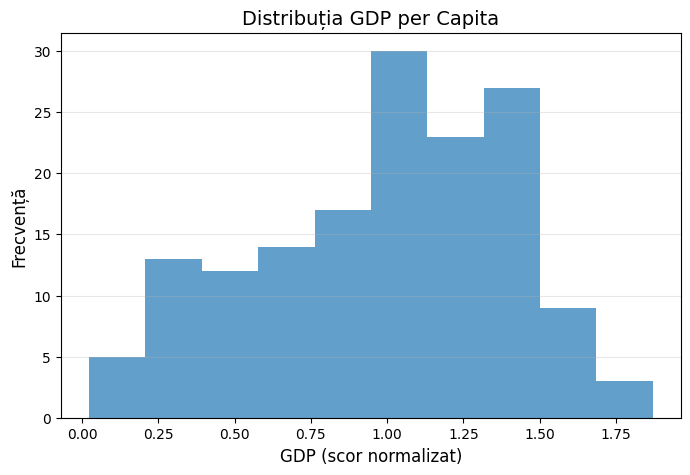

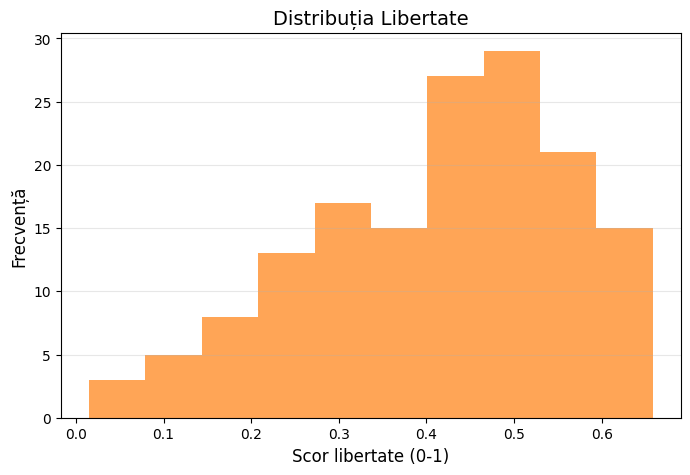

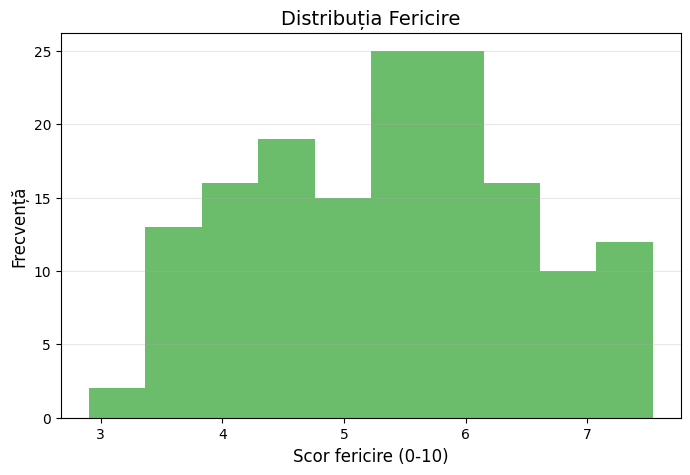

Data v2


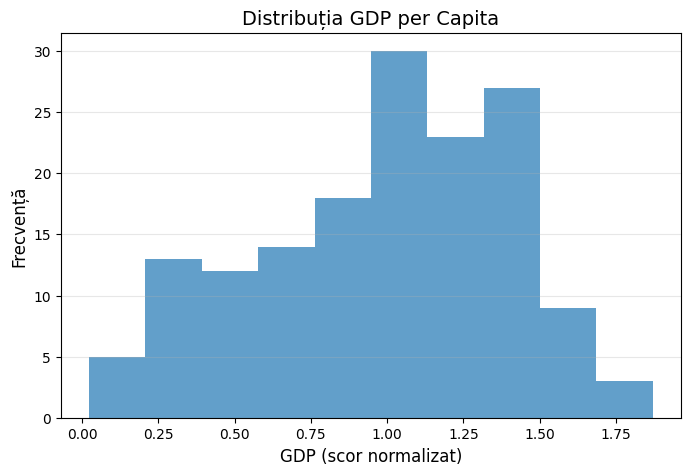

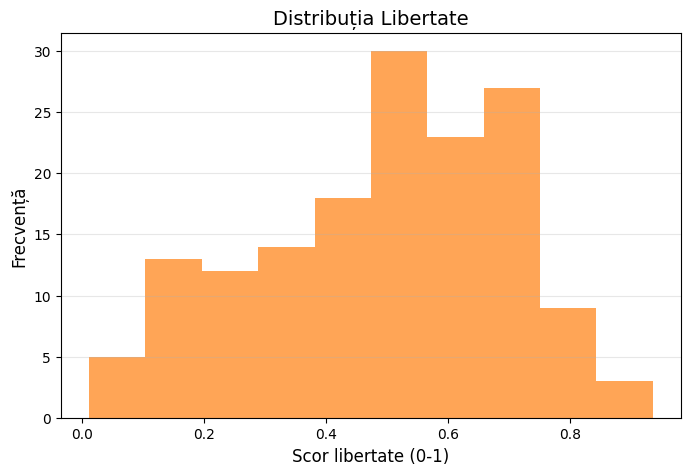

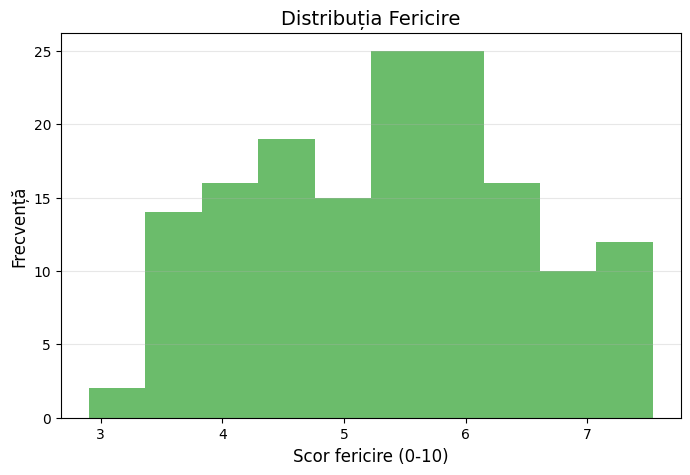

Data v3


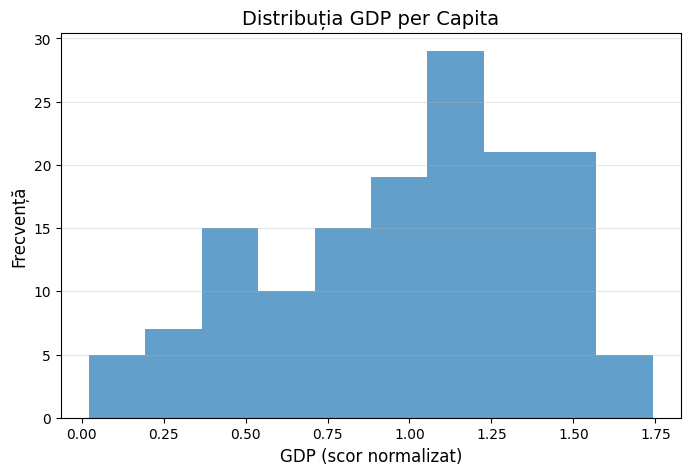

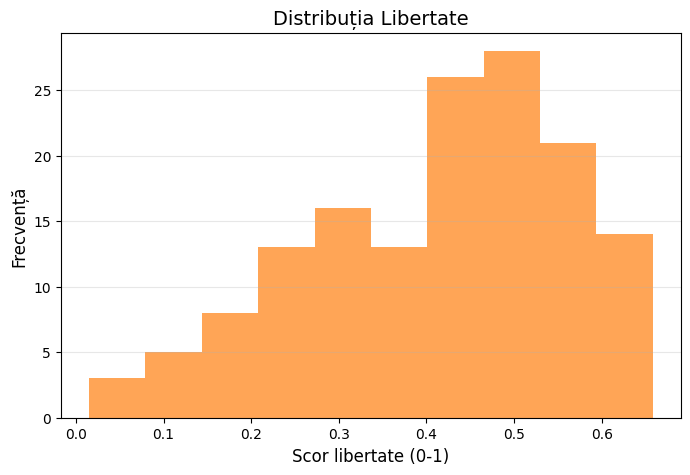

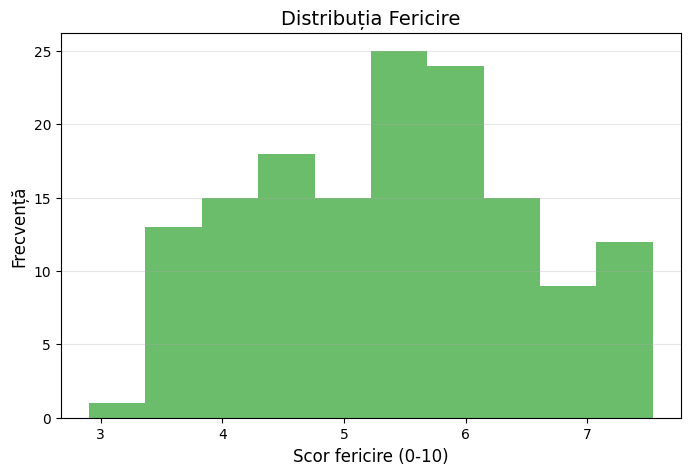

In [33]:
histograma(gdp1, 'GDP per Capita', 'GDP (scor normalizat)', color='#1f77b4')
histograma(freedom1, 'Libertate', 'Scor libertate (0-1)', color='#ff7f0e')
histograma(happiness1, 'Fericire', 'Scor fericire (0-10)', color='#2ca02c')

print("Data v2")
histograma(gdp2, 'GDP per Capita', 'GDP (scor normalizat)', color='#1f77b4')
histograma(freedom2, 'Libertate', 'Scor libertate (0-1)', color='#ff7f0e')
histograma(happiness2, 'Fericire', 'Scor fericire (0-10)', color='#2ca02c')

print("Data v3")
histograma(gdp3, 'GDP per Capita', 'GDP (scor normalizat)', color='#1f77b4')
histograma(freedom3, 'Libertate', 'Scor libertate (0-1)', color='#ff7f0e')
histograma(happiness3, 'Fericire', 'Scor fericire (0-10)', color='#2ca02c')


In [17]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

def verificare_liniaritare_3d(inputs, outputs, figsize=(14, 10)):
    """
    La regresia simpla verificam daca punctele sunt apoximativ pe o dreata, in acest caz verificam daca punctele
    par sa se aseze aproximativ pe un plan
    """
    gdp = [x[0] for x in inputs]
    freedom = [x[1] for x in inputs]
    happiness = outputs

    fig = plt.figure(figsize=figsize)
    ax = fig.add_subplot(111, projection='3d')

    scatter = ax.scatter(
        gdp, freedom, happiness,
        s=80
    )

    ax.set_xlabel('GDP per Capita\n(scor normalizat)', fontsize=12, linespacing=3)
    ax.set_ylabel('Freedom Score\n(0-1 scalat)', fontsize=12, linespacing=3)
    ax.set_zlabel('Happiness Score\n(0-10)', fontsize=12, linespacing=3)

    plt.title('Relația dintre GDP, Freedom și Happiness\n(Visualizare 3D)',
             fontsize=14, pad=20)
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

Date v1


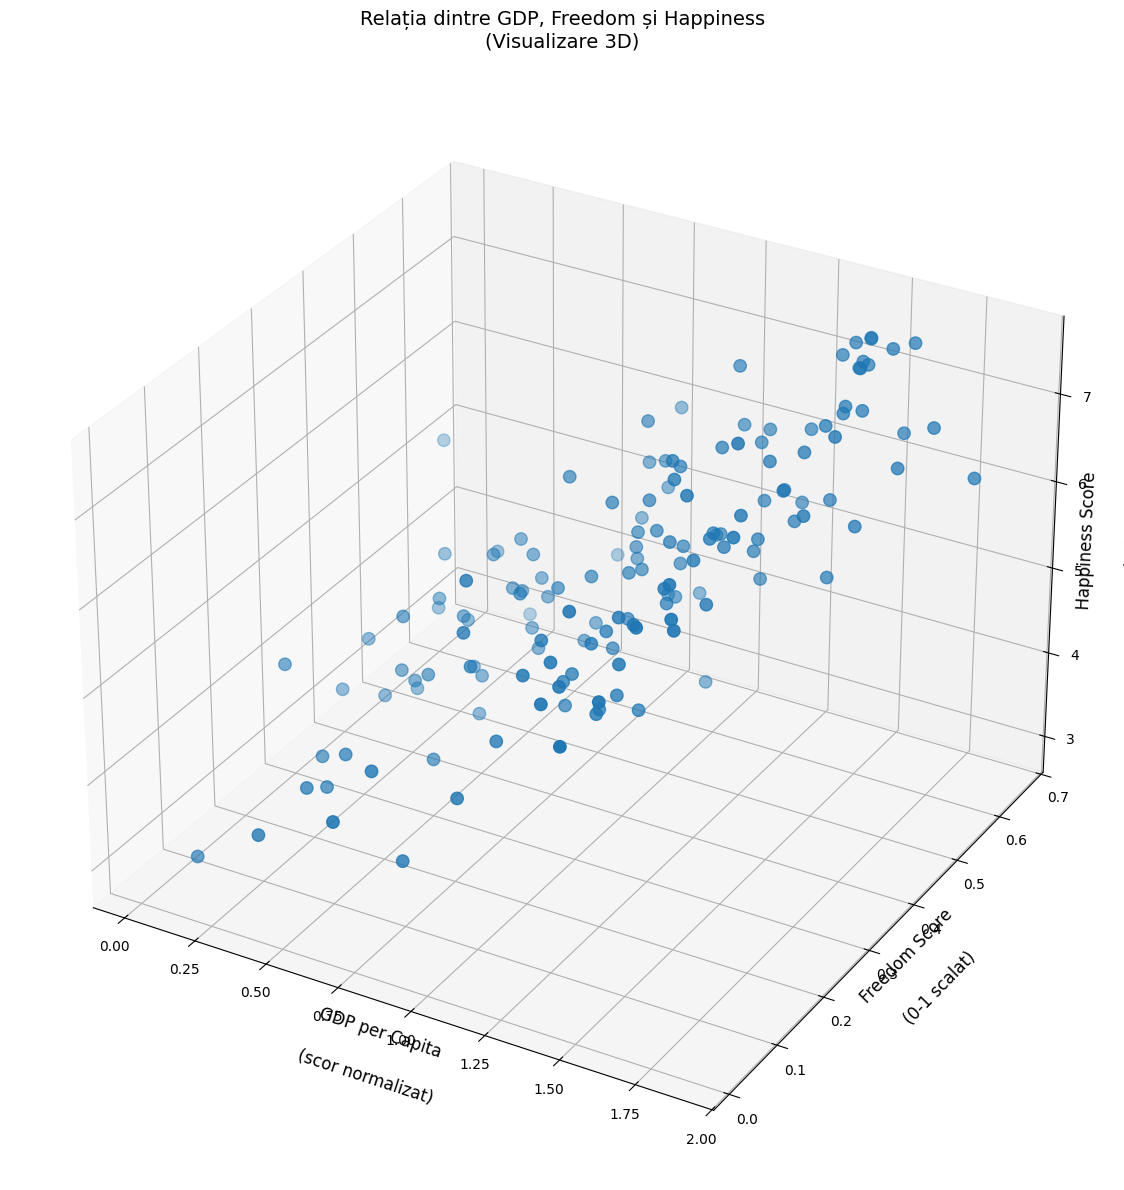

Date v2


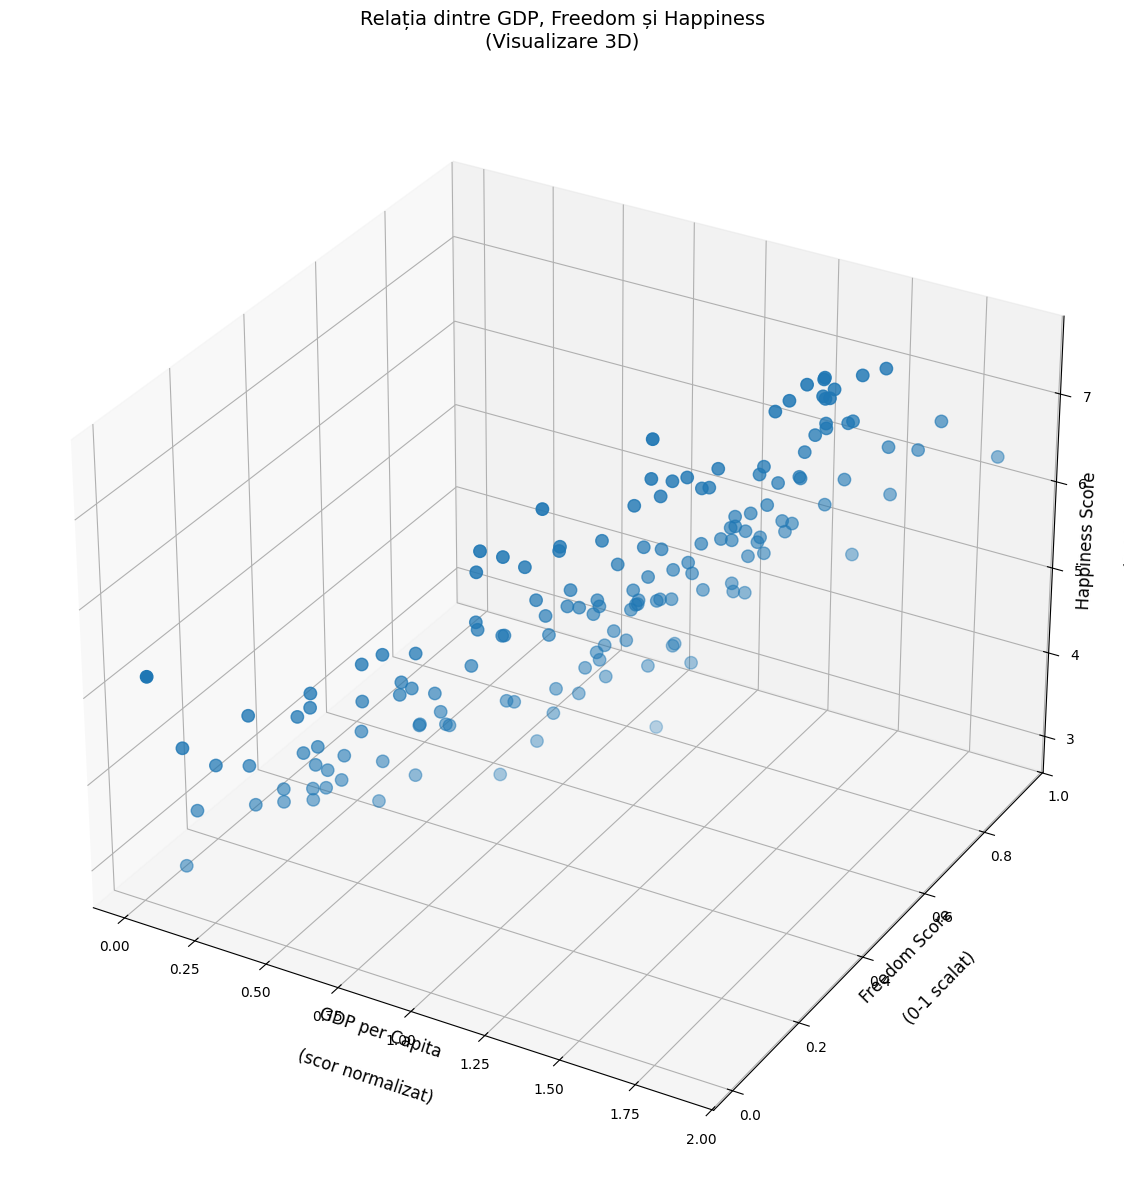

Date v3


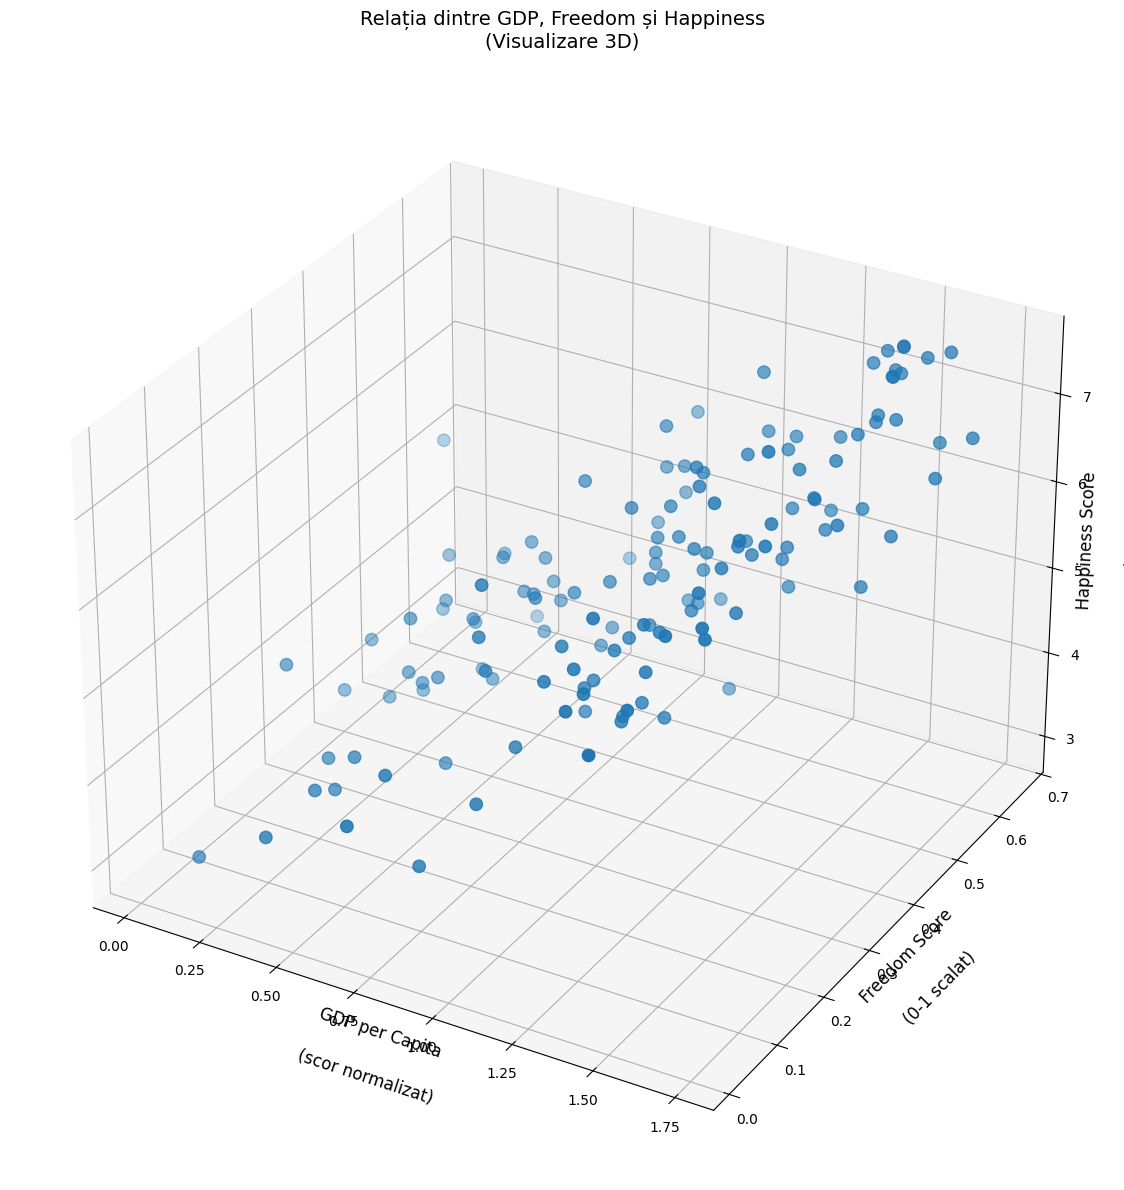

In [18]:
print("Date v1")
verificare_liniaritare_3d(inputs1, outputs1, figsize=(16, 12))

print("Date v2")
verificare_liniaritare_3d(inputs2, outputs2, figsize=(16, 12))

print("Date v3")
verificare_liniaritare_3d(inputs3, outputs3, figsize=(16, 12))


In [19]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# Divizarea datelor din nou in 80% antrenare si 20% testare
def divizare_date(inputs, outputs):
  np.random.seed(5)
  indexes = np.arange(len(inputs))
  trainSample = np.random.choice(indexes, int(0.8 * len(inputs)), replace=False)
  validationSample = np.setdiff1d(indexes, trainSample)

  trainGDP = [inputs[i][0] for i in trainSample]
  trainFreedom = [inputs[i][1] for i in trainSample]
  trainHappiness = [outputs[i] for i in trainSample]

  valGDP = [inputs[i][0] for i in validationSample]
  valFreedom = [inputs[i][1] for i in validationSample]
  valHappiness = [outputs[i] for i in validationSample]

  fig = plt.figure(figsize=(14, 10))
  ax = fig.add_subplot(111, projection='3d')

  ax.scatter(trainGDP, trainFreedom, trainHappiness,
            c='blue', marker='o', s=40, alpha=0.7, label='Antrenare')

  ax.scatter(valGDP, valFreedom, valHappiness,
            c='red', marker='^', s=40, alpha=0.7, label='Validare')

  ax.set_xlabel('GDP per Capita', fontsize=12)
  ax.set_ylabel('Freedom Score', fontsize=12)
  ax.set_zlabel('Happiness Score', fontsize=12)
  ax.set_title('Împărțirea datelor în Antrenare/Validare (3D)', fontsize=14, pad=20)
  ax.legend(fontsize=12)
  ax.grid(True, alpha=0.3)

  ax.view_init(elev=25, azim=45)

  plt.tight_layout()
  plt.show()

  print(f"Statistici împărțire:")
  print(f"- Total instanțe: {len(inputs)}")
  print(f"- Antrenare: {len(trainSample)} ({len(trainSample)/len(inputs):.1%})")
  print(f"- Validare: {len(validationSample)} ({len(validationSample)/len(inputs):.1%})")

  return trainGDP, trainFreedom, trainHappiness, valGDP, valFreedom, valHappiness


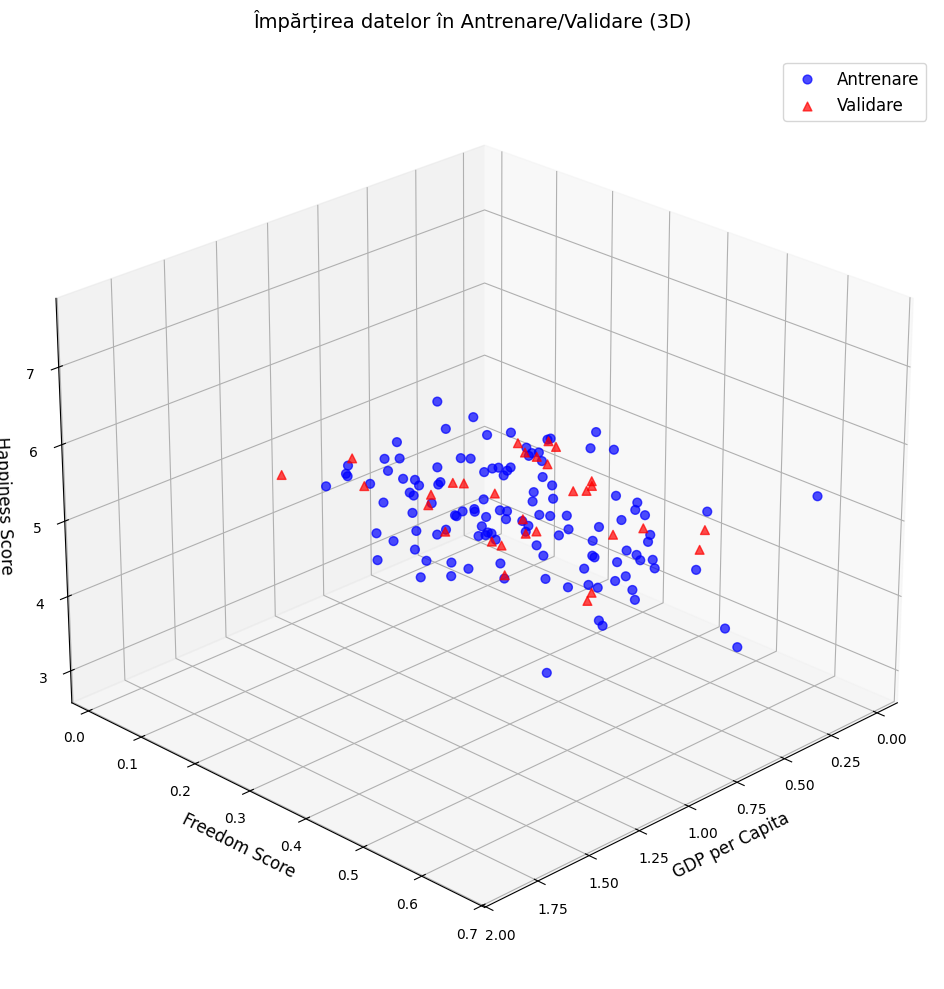

Statistici împărțire:
- Total instanțe: 153
- Antrenare: 122 (79.7%)
- Validare: 31 (20.3%)


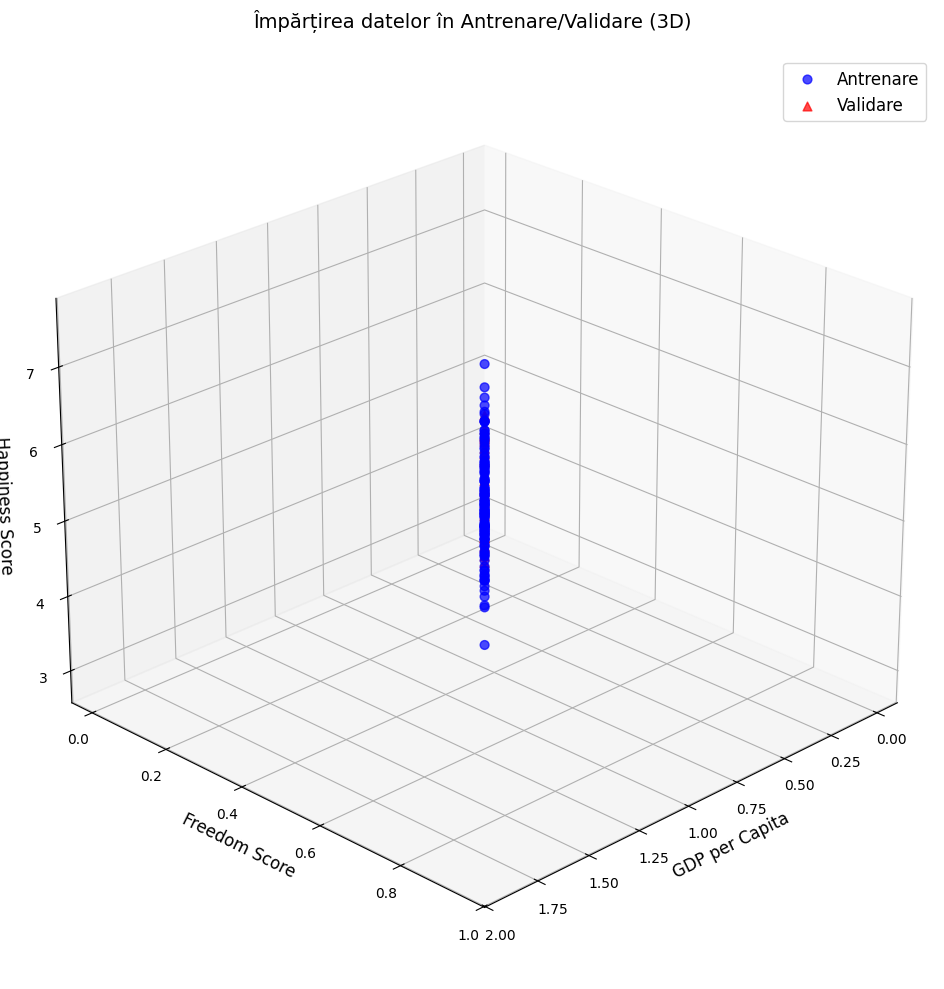

Statistici împărțire:
- Total instanțe: 154
- Antrenare: 123 (79.9%)
- Validare: 31 (20.1%)


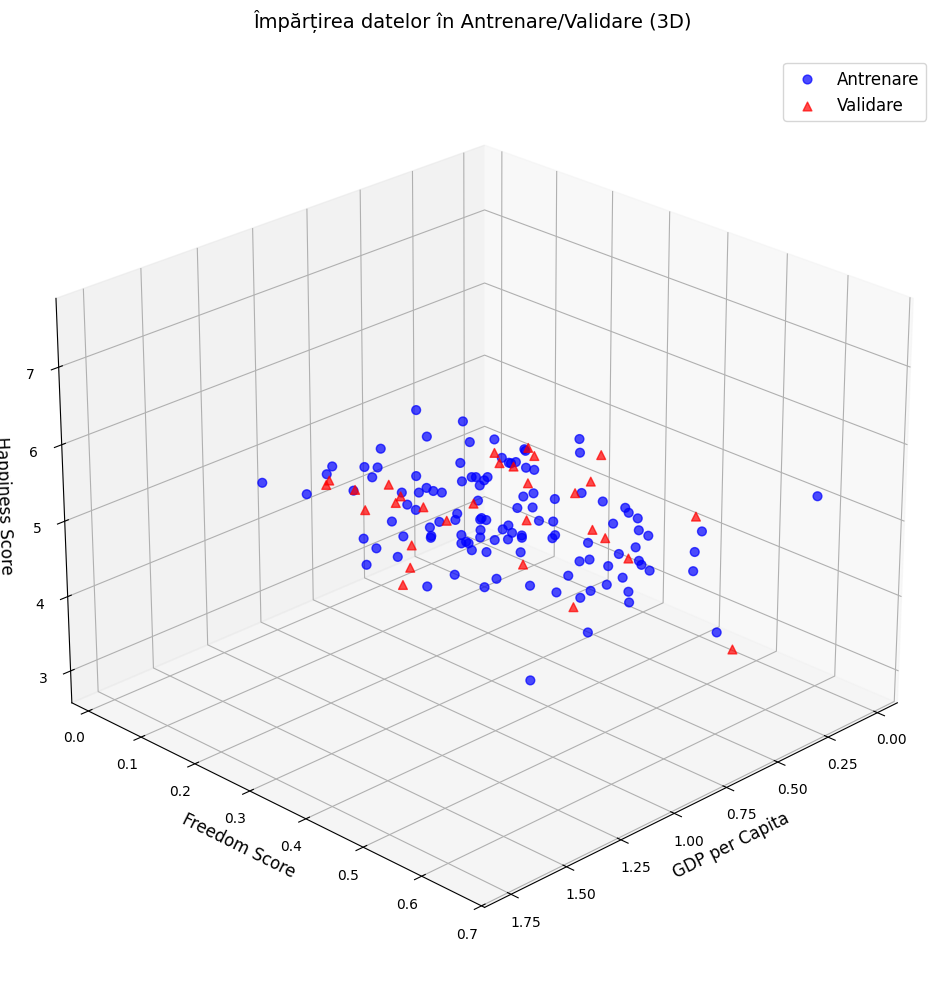

Statistici împărțire:
- Total instanțe: 147
- Antrenare: 117 (79.6%)
- Validare: 30 (20.4%)


In [20]:
trainGDP1, trainFreedom1, trainHappiness1, valGDP1, valFreedom1, valHappiness1 = divizare_date(inputs1, outputs1)
trainGDP2, trainFreedom2, trainHappiness2, valGDP2, valFreedom2, valHappiness2 = divizare_date(inputs2, outputs2)
trainGDP3, trainFreedom3, trainHappiness3, valGDP3, valFreedom3, valHappiness3 = divizare_date(inputs3, outputs3)


In [21]:
# Antrenarea modelului folosind tool
import numpy as np
from sklearn import linear_model

def antrenare_model_cu_tool_3d(trainGDP, trainFreedom, trainOutputs):

  # Pentru a evita erorile de tipul: una dintre liste are mai putine valori, luam lungimea minima
  print(f"Lungimi liste originale:")
  print(f"- trainGDP: {len(trainGDP)}")
  print(f"- trainFreedom: {len(trainFreedom)}")
  print(f"- trainOutputs: {len(trainOutputs)}")

  min_len = min(len(trainGDP), len(trainFreedom), len(trainOutputs))
  print(f"\nSe vor folosi primele {min_len} valori din fiecare listă")

  trainGDP = trainGDP[:min_len]
  trainFreedom = trainFreedom[:min_len]
  trainOutputs = trainOutputs[:min_len]

  X_train = np.column_stack((trainGDP, trainFreedom)) # formam matricea cu datele de la gdp si freedom
  y_train = np.array(trainOutputs) # datele de la happiness

  # Formula modelului este: w = [(X^T * X)]^(-1) * X^T * Y

  try:
      regressor = linear_model.LinearRegression()
      regressor.fit(X_train, y_train)
      print(f"Functia de regresie f(x) = {regressor.intercept_:.4f} + {regressor.coef_[0]}*x1 + {regressor.coef_[1]}*x2 \n")

  except Exception as e:
      print(f"\nEroare la antrenare: {str(e)}")

  return X_train, y_train, regressor

In [22]:
X_train1, y_train1, regressor1 = antrenare_model_cu_tool_3d(trainGDP1, trainFreedom1, trainHappiness1)
X_train2, y_train2, regressor2 = antrenare_model_cu_tool_3d(trainGDP2, trainFreedom2, trainHappiness2)
X_train3, y_train3, regressor3 = antrenare_model_cu_tool_3d(trainGDP3, trainFreedom3, trainHappiness3)


Lungimi liste originale:
- trainGDP: 122
- trainFreedom: 122
- trainOutputs: 122

Se vor folosi primele 122 valori din fiecare listă
Functia de regresie f(x) = 2.5734 + 1.88383836211687*x1 + 2.1945991815049575*x2 

Lungimi liste originale:
- trainGDP: 123
- trainFreedom: 123
- trainOutputs: 123

Se vor folosi primele 123 valori din fiecare listă
Functia de regresie f(x) = 3.2111 + -1849328.0285375922*x1 + 3698660.3397609033*x2 

Lungimi liste originale:
- trainGDP: 117
- trainFreedom: 117
- trainOutputs: 117

Se vor folosi primele 117 valori din fiecare listă
Functia de regresie f(x) = 2.5506 + 1.8752990569583812*x1 + 2.3668306494341858*x2 



In [46]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

def vizualizare_regresie_3d(X_train, y_train, regressor):

    w0 = regressor.intercept_
    w1, w2 = regressor.coef_

    gdp = X_train[:, 0]
    freedom = X_train[:, 1]

    gdp_range = np.linspace(min(gdp), max(gdp), 20)
    freedom_range = np.linspace(min(freedom), max(freedom), 20)
    gdp_grid, freedom_grid = np.meshgrid(gdp_range, freedom_range)

    happiness_grid = w0 + w1*gdp_grid + w2*freedom_grid

    fig = plt.figure(figsize=(14, 10))
    ax = fig.add_subplot(111, projection='3d')

    surf = ax.plot_surface(gdp_grid, freedom_grid, happiness_grid,
                           alpha=0.7,
                         label=f'Model: {w0:.2f} + {w1:.2f}*GDP + {w2:.2f}*Freedom')

    ax.scatter(gdp, freedom, y_train,
              c='red', s=40, alpha=1,
              label='Date observate')

    ax.set_xlabel('GDP per Capita', fontsize=12, labelpad=10)
    ax.set_ylabel('Freedom Score', fontsize=12, labelpad=10)
    ax.set_zlabel('Happiness Score', fontsize=12, labelpad=10)
    ax.set_title('Regresie liniară multiplă: GDP și Freedom vs Happiness',
                fontsize=14, pad=20)

    ax.view_init(elev=25, azim=45)


    ax.legend(fontsize=12, bbox_to_anchor=(1.05, 1), loc='upper left')

    plt.tight_layout()
    plt.show()

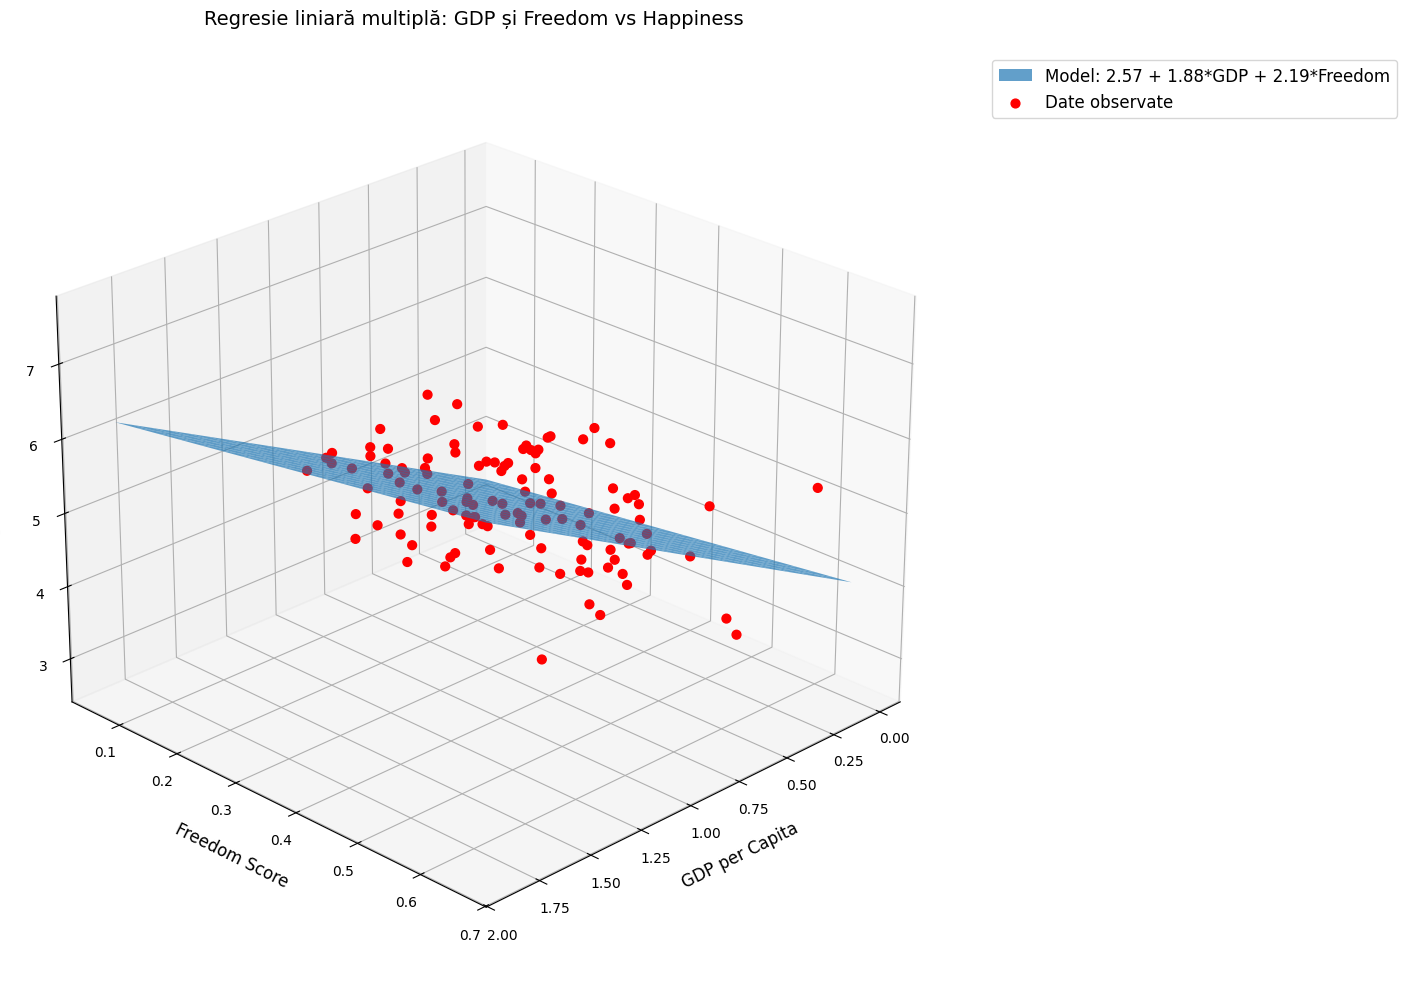

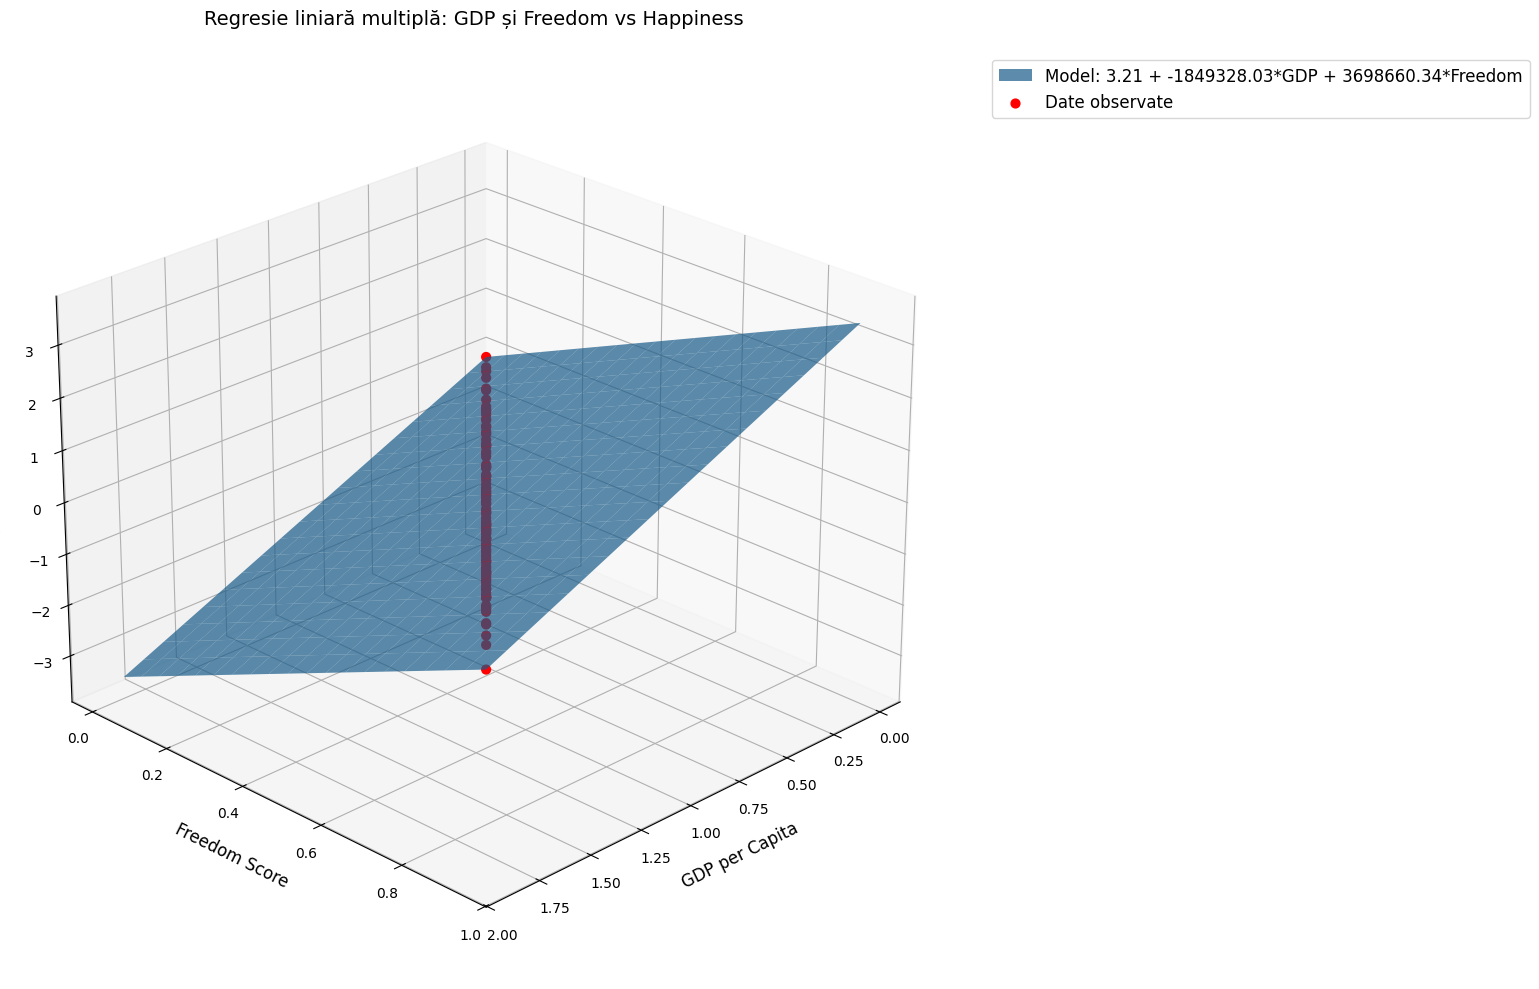

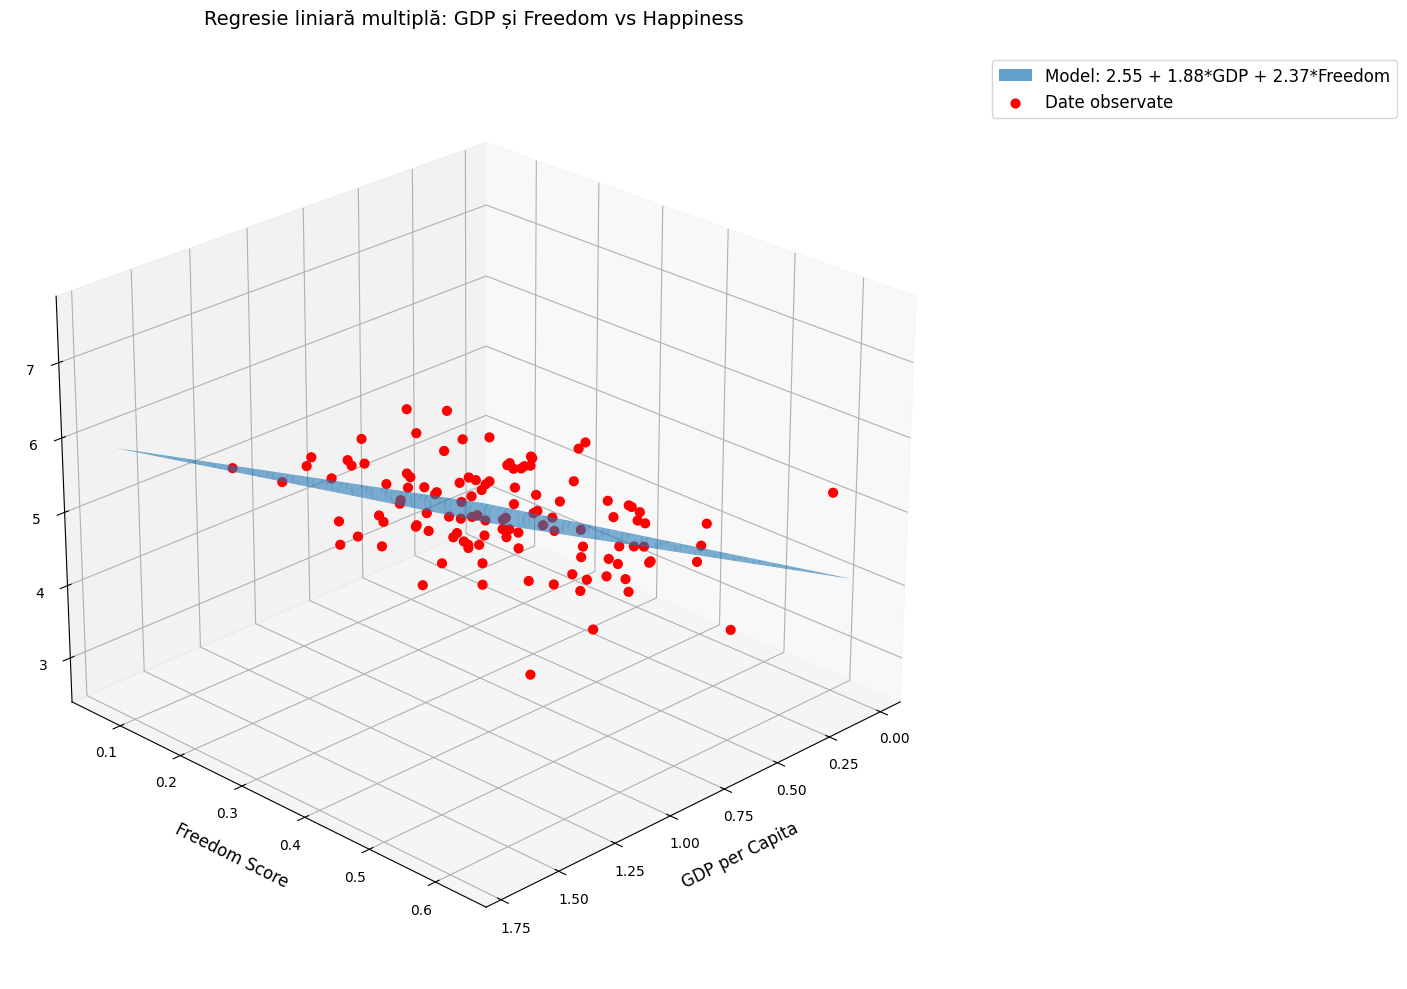

In [47]:
vizualizare_regresie_3d(X_train1, y_train1, regressor1)
vizualizare_regresie_3d(X_train2, y_train2, regressor2)
vizualizare_regresie_3d(X_train3, y_train3, regressor3)

In [48]:
def predictii_3d(valGDP, valFreedom, validationOutputs, regressor):
    # Functia curenta face predictii
    validationInputs = np.column_stack((valGDP, valFreedom))
    validationOutputs = np.array(validationOutputs)

    computedValidationOutputs = regressor.predict(validationInputs)
    errors = validationOutputs - computedValidationOutputs
    mse = np.mean(errors ** 2)

    fig = plt.figure(figsize=(14, 10))
    ax = fig.add_subplot(111, projection='3d')

    ax.scatter(valGDP, valFreedom, validationOutputs,
               c='green', marker='^', s=50, label='Valori reale')

    ax.scatter(valGDP, valFreedom, computedValidationOutputs,
               c='blue', marker='o', s=50, label='Valori prezise')

    for gdp, freedom, real, pred in zip(valGDP, valFreedom, validationOutputs, computedValidationOutputs):
        ax.plot([gdp, gdp], [freedom, freedom], [real, pred], 'r--', alpha=0.3)

    ax.set_xlabel('GDP per Capita')
    ax.set_ylabel('Freedom Score')
    ax.set_zlabel('Happiness Score')
    ax.set_title(f'Comparație valori reale vs prezise\nMSE: {mse:.4f}')
    ax.legend()
    plt.show()

    return computedValidationOutputs

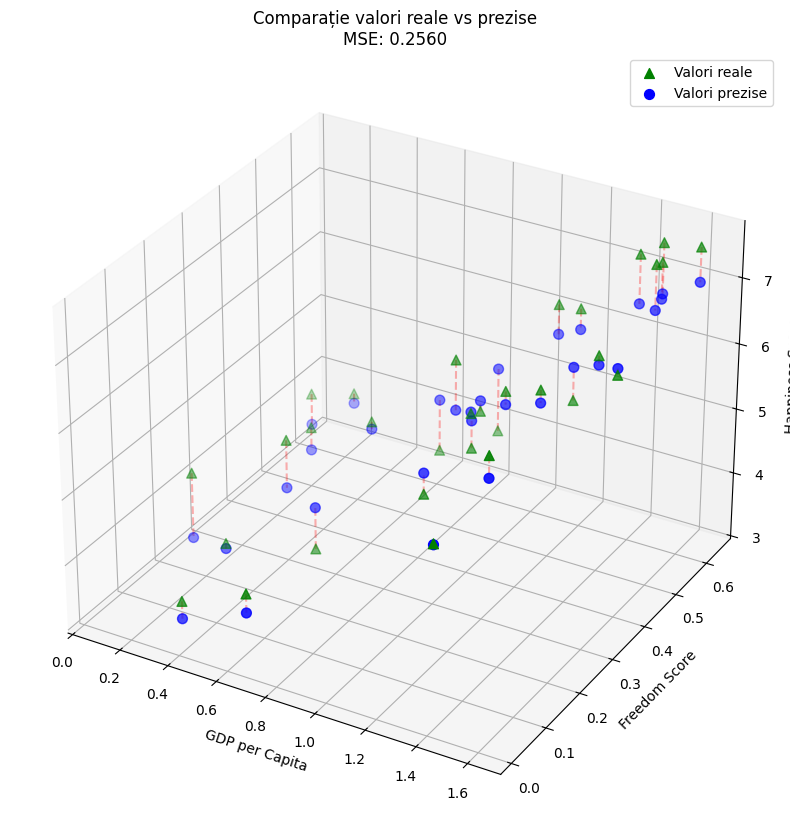

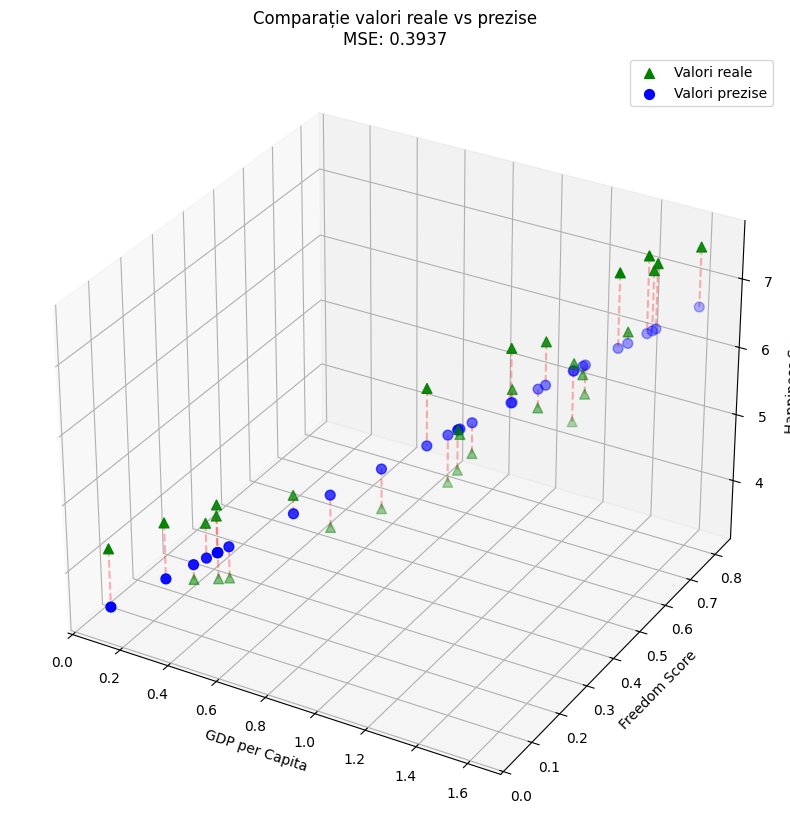

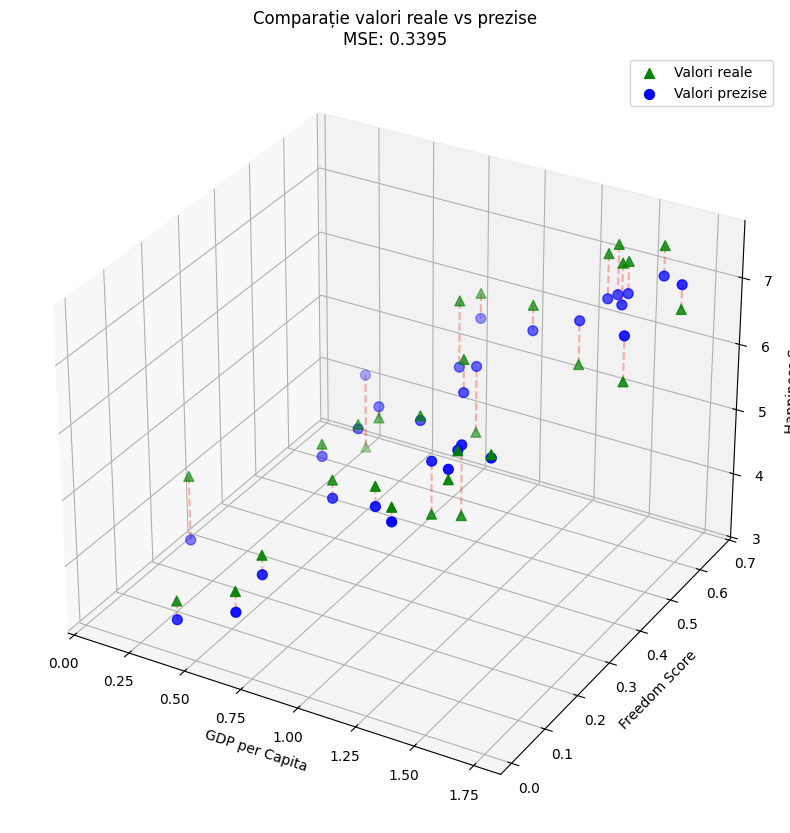

In [49]:
computedValidationOutputs1 = predictii_3d(valGDP1, valFreedom1, valHappiness1, regressor1)
computedValidationOutputs2 = predictii_3d(valGDP2, valFreedom2, valHappiness2, regressor2)
computedValidationOutputs3 = predictii_3d(valGDP3, valFreedom3, valHappiness3, regressor3)

In [50]:
from sklearn.metrics import mean_squared_error, mean_absolute_error

def evaluare_model_3d(validationOutputs, computedValidationOutputs):
    n = len(validationOutputs)

    mse_manual = 0.0
    mae_manual = 0.0

    for real, pred in zip(validationOutputs, computedValidationOutputs):
        mse_manual += (real - pred) ** 2
        mae_manual += abs(real - pred)

    mse_manual /= n
    mae_manual /= n

    mse_tool = mean_squared_error(validationOutputs, computedValidationOutputs)
    mae_tool = mean_absolute_error(validationOutputs, computedValidationOutputs)

    print("----- MSE -----")
    print("Manual:", mse_manual)
    print("Tool:  ", mse_tool)

    print("\n----- MAE -----")
    print("Manual:", mae_manual)
    print("Tool:  ", mae_tool)

    return mse_manual, mse_tool, mae_manual, mae_tool

In [52]:
print("FISEIRUL 1")
validationInputs1 = np.column_stack((valGDP1, valFreedom1))
computedValidationOutputs1 = regressor1.predict(validationInputs1)
evaluare_model_3d(valHappiness1, computedValidationOutputs1)

print("\nFISEIRUL 2")
validationInputs2 = np.column_stack((valGDP2, valFreedom2))
computedValidationOutputs2 = regressor2.predict(validationInputs2)
evaluare_model_3d(valHappiness2, computedValidationOutputs2)

print("\nFISEIRUL 3")
validationInputs3 = np.column_stack((valGDP3, valFreedom3))
computedValidationOutputs3 = regressor3.predict(validationInputs3)
evaluare_model_3d(valHappiness3, computedValidationOutputs3)

FISEIRUL 1
----- MSE -----
Manual: 0.25596467938646805
Tool:   0.25596467938646805

----- MAE -----
Manual: 0.4223177884943397
Tool:   0.4223177884943398

FISEIRUL 2
----- MSE -----
Manual: 0.3936672873315609
Tool:   0.3936672873315609

----- MAE -----
Manual: 0.547810636562233
Tool:   0.547810636562233

FISEIRUL 3
----- MSE -----
Manual: 0.3395242100949325
Tool:   0.3395242100949325

----- MAE -----
Manual: 0.4812406916296992
Tool:   0.4812406916296992


(np.float64(0.3395242100949325),
 0.3395242100949325,
 np.float64(0.4812406916296992),
 0.4812406916296992)

# PROBLEMA 2 - COD PERSONAL PENTRU REGRESIE

In [2]:
import numpy as np
from math import exp
from math import log2
from numpy.linalg import inv

class Codu_meu_pentru_regresie_simpla:
    def __init__(self):
        self.intercept_ = 0.0
        self.coef_ = 0.0

    def fit(self, x, y):
      # Pentru acest cod pur si simplu aplicam formula
      # w1 = (n * sxy - sx * sy) / (n * sx2 - sx * sx)
      # w0 = (sy - w1 * sx) / n
        sx = sum(x)
        sy = sum(y)
        sx2 = sum(i * i for i in x)
        sxy = sum(i * j for (i,j) in zip(x, y))
        w1 = (len(x) * sxy - sx * sy) / (len(x) * sx2 - sx * sx)
        w0 = (sy - w1 * sx) / len(x)
        self.intercept_, self.coef_ =  w0, w1

    def predict(self, x):
        if (isinstance(x[0], list)):
            return [self.intercept_ + self.coef_ * val[0] for val in x]
        else:
            return [self.intercept_ + self.coef_ * val for val in x]

In [57]:
import numpy as np
from math import exp
from math import log2
from numpy.linalg import inv

class Codul_meu_pentru_regresie_multipla:
    def __init__(self):
        self.intercept_ = 0.0
        self.coef_ = [0.0, 0.0]

    # Formula pe care se bazeaza algoritmul este: [(X^T * X)]^(-1) * [X^T * Y]
    # In cazul acesta avem doua abordari diferite
    # 1. Metoda implementata: Calculam mai intai X^T * X si X^T * Y iar ecuatia devine A * W = B, iar pentru acest sistem putem aplica metoda lui Cramer,
    # unde fiecare valoare x = det(x) / det
    # 2. Metoda in care facem calculul exaxt asa cum este si calculam invera matricei
    # In cod, prima abordare este mai simpla
    def fit(self, x, y):

        n = len(x) # calculam numarul de exemple

        # Incepem prin calcularea sumelor, totalul valorilor pentru gdp, freedom, happiness
        sum_x1 = sum(val[0] for val in x) # suma tuturor valorilor GDP
        sum_x2 = sum(val[1] for val in x) # suma tuturor valorilor Freedom
        sum_y = sum(y) # suma tututor valorilor Happiness

        # Patratele
        sum_x1_sq = sum(val[0] * val[0] for val in x)
        sum_x2_sq = sum(val[1] * val[1] for val in x)

        # Produsul dintre GDP si Freedom
        sum_x1x2 = sum(val[0]*val[1] for val in x)

        # Corelatii:
        # GDP vs Happiness
        sum_x1y = sum(val[0]*yi for val, yi in zip(x, y))
        sum_x2y = sum(val[1]*yi for val, yi in zip(x, y))

        # Forma generală -- obtinuta prin derivarea partiala in functie de fiecare coeficient
        # n*w0 + sum_x1*w1 + sum_x2*w2 = sum_y
        # sum_x1*w0 + sum_x1_sq*w1 + sum_x1x2*w2 = sum_x1y
        # sum_x2*w0 + sum_x1x2*w1 + sum_x2_sq*w2 = sum_x2y

        # 3. Rezolvăm sistemul (folosind metoda lui Cramer)
        # Calculăm determinanții
        det = n * (sum_x1_sq*sum_x2_sq - sum_x1x2*sum_x1x2) \
            - sum_x1 * (sum_x1*sum_x2_sq - sum_x2*sum_x1x2) \
            + sum_x2 * (sum_x1*sum_x1x2 - sum_x2*sum_x1_sq)

        det_w0 = sum_y * (sum_x1_sq*sum_x2_sq - sum_x1x2*sum_x1x2) \
              - sum_x1 * (sum_x1y*sum_x2_sq - sum_x2y*sum_x1x2) \
              + sum_x2 * (sum_x1y*sum_x1x2 - sum_x2y*sum_x1_sq)

        det_w1 = n * (sum_x1y*sum_x2_sq - sum_x2y*sum_x1x2) \
              - sum_y * (sum_x1*sum_x2_sq - sum_x2*sum_x1x2) \
              + sum_x2 * (sum_x1*sum_x2y - sum_x2*sum_x1y)

        det_w2 = n * (sum_x1_sq*sum_x2y - sum_x1x2*sum_x1y) \
              - sum_x1 * (sum_x1*sum_x2y - sum_x2*sum_x1y) \
              + sum_y * (sum_x1*sum_x1x2 - sum_x2*sum_x1_sq)

        self.intercept_ = det_w0 / det
        w1 = det_w1 / det
        w2 = det_w2 / det
        self.coef_ = [w1, w2]

    def predict(self, x):
        if isinstance(x, list) and len(x) > 0 and isinstance(x[0], list):
            return [self.intercept_ + self.coef_[0]*val[0] + self.coef_[1]*val[1] for val in x]

        elif isinstance(x, np.ndarray) and x.ndim == 2:
            return np.array([self.intercept_ + self.coef_[0]*val[0] + self.coef_[1]*val[1] for val in x])

        else:
            x1 = x[0] if isinstance(x, (list, np.ndarray)) else x
            x2 = x[1] if isinstance(x, (list, np.ndarray)) and len(x) > 1 else 0
            return self.intercept_ + self.coef_[0]*x1 + self.coef_[1]*x2

# PROBLEMA 2 - PENTRU FAMILY

In [23]:
def incarcare_date_github(github_raw_url, inputVariabName, outputVariabName):
    # Descarcă fișierul de pe GitHub
    response = urllib.request.urlopen(github_raw_url)
    lines = [line.decode('utf-8') for line in response.readlines()]

    data = []
    dataNames = []
    csv_reader = csv.reader(lines, delimiter=',')
    for i, row in enumerate(csv_reader):
        if i == 0:
            dataNames = row
        else:
            data.append(row)

    selectedVariable = dataNames.index(inputVariabName)
    inputs = [float(data[i][selectedVariable]) for i in range(len(data))]
    selectedOutput = dataNames.index(outputVariabName)
    outputs = [float(data[i][selectedOutput]) for i in range(len(data))]

    return inputs, outputs

In [25]:
inputs1, outputs1 = incarcare_date_github(github_raw_url1, 'Family', 'Happiness.Score')
inputs2, outputs2 = incarcare_date_github(github_raw_url2, 'Family', 'Happiness.Score')
inputs3, outputs3 = incarcare_date_github(github_raw_url3, 'Family', 'Happiness.Score')

In [26]:
def diagrama(x, variableName):
    n, bins, patches = plt.hist(x, 10)
    plt.title('Histogram of ' + variableName)
    plt.show()

v1


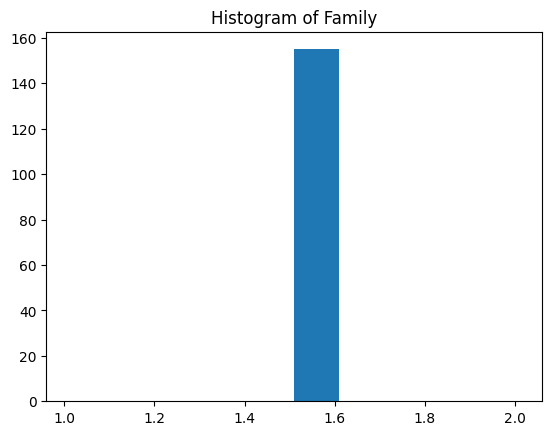

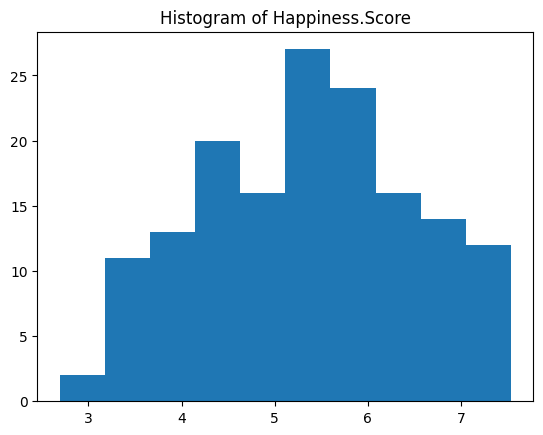

v2


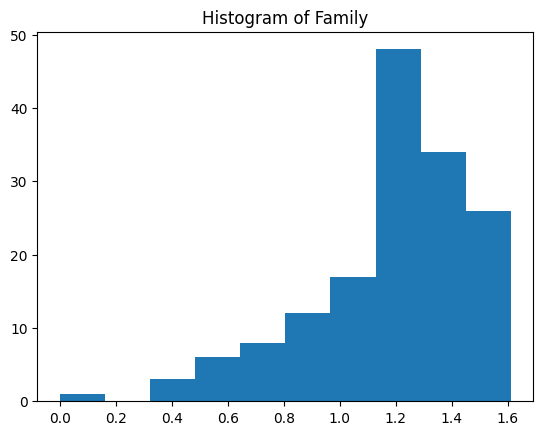

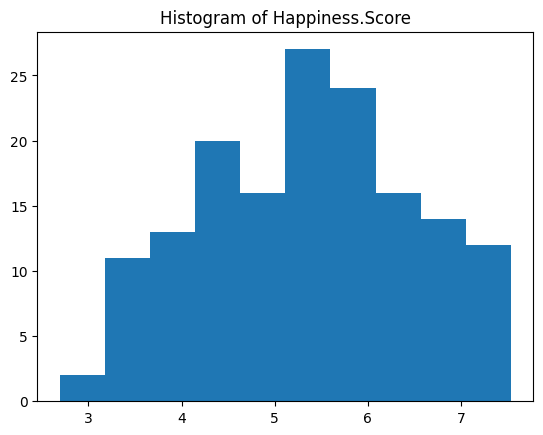

v3


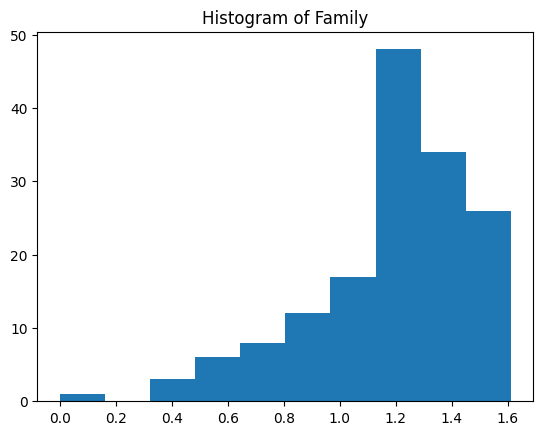

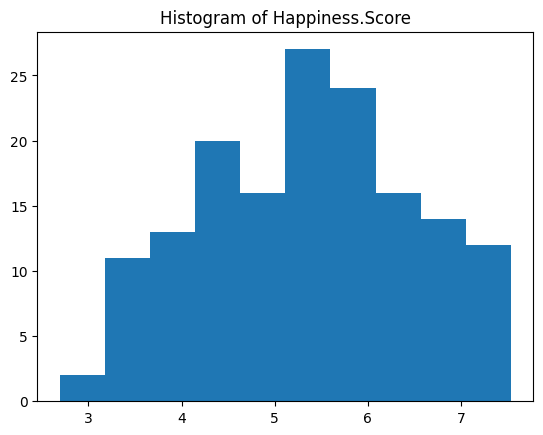

In [28]:
print("v1")
diagrama(inputs1, 'Family')
diagrama(outputs1, 'Happiness.Score')

print("v2")
diagrama(inputs2, 'Family')
diagrama(outputs2, 'Happiness.Score')

print("v3")
diagrama(inputs3, 'Family')
diagrama(outputs3, 'Happiness.Score')

In [29]:
def verificarea_liniaritatii(inputs, outputs):
    plt.plot(inputs, outputs, 'ro')
    plt.xlabel('Family')
    plt.ylabel('Happiness')
    plt.title('Family vs Happiness')
    plt.show()

v1


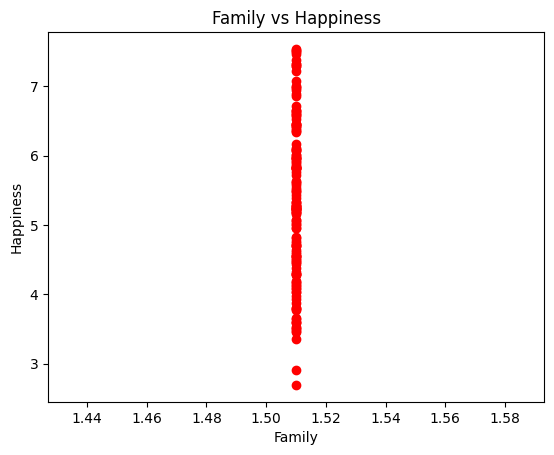

v2


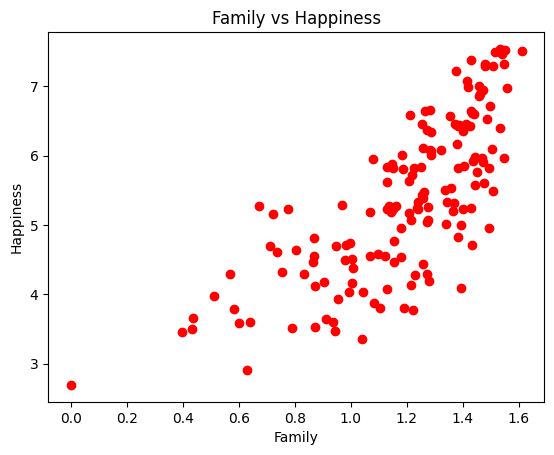

v3


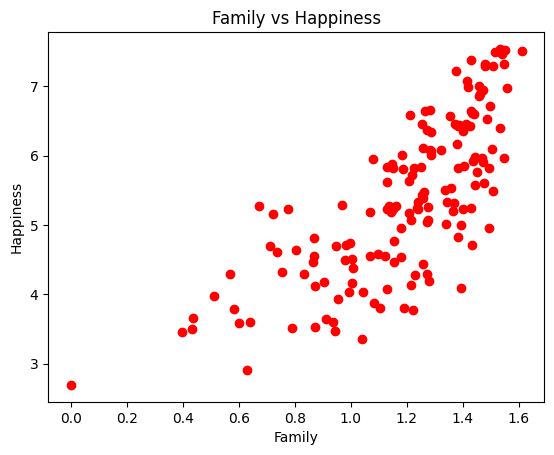

In [30]:
print("v1")
verificarea_liniaritatii(inputs1, outputs1)

print("v2")
verificarea_liniaritatii(inputs2, outputs2)

print("v3")
verificarea_liniaritatii(inputs3, outputs3)

In [32]:
def data_split_family_1(inputs, outputs):
    np.random.seed(5)
    indexes = [i for i in range(len(inputs))]
    trainSample = np.random.choice(indexes, int(0.8 * len(inputs)), replace=False)
    validationSample = [i for i in indexes if not i in trainSample]

    trainInputs = [inputs[i] for i in trainSample]
    trainOutputs = [outputs[i] for i in trainSample]

    validationInputs = [inputs[i] for i in validationSample]
    validationOutputs = [outputs[i] for i in validationSample]

    plt.plot(trainInputs, trainOutputs, 'ro', label='training data')
    plt.plot(validationInputs, validationOutputs, 'g^', label='validation data')
    plt.title('train and validation data')
    plt.xlabel('Family')
    plt.ylabel('Happiness')
    plt.legend()
    plt.show()

    return trainInputs, trainOutputs, validationInputs, validationOutputs

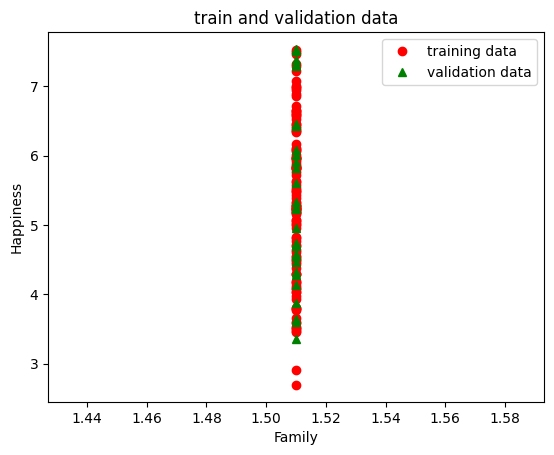

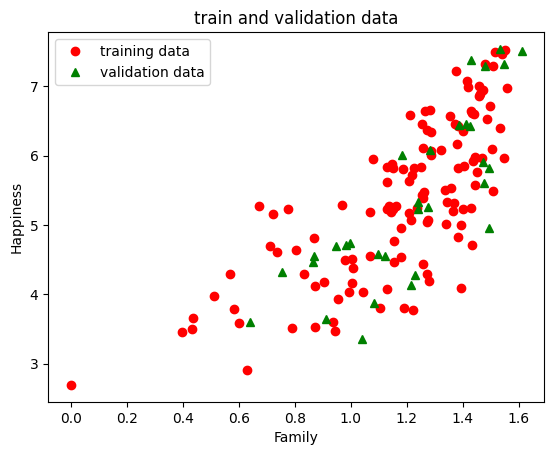

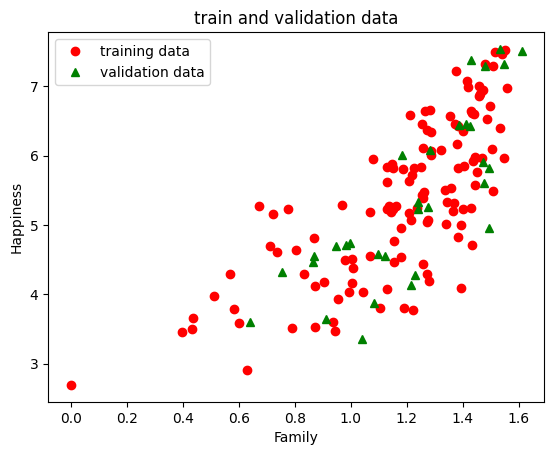

In [33]:
trainInputs1, trainOutputs1, validationInputs1, validationOutputs1 = data_split_family_1(inputs1, outputs1)

trainInputs2, trainOutputs2, validationInputs2, validationOutputs2 = data_split_family_1(inputs2, outputs2)

trainInputs3, trainOutputs3, validationInputs3, validationOutputs3 = data_split_family_1(inputs3, outputs3)

In [36]:
def antrenare_cod_propriu(trainInputs, trainOutputs):
    regressor = Codu_meu_pentru_regresie_simpla()
    regressor.fit(trainInputs, trainOutputs)
    w0, w1 = regressor.intercept_, regressor.coef_
    print('Functia de regresie: f(x) = ', w0, ' + ', w1, ' * x')
    return regressor, w0, w1

In [37]:
regressor1, w01, w11 = antrenare_cod_propriu(trainInputs1, trainOutputs1)
regressor2, w02, w12 = antrenare_cod_propriu(trainInputs2, trainOutputs2)
regressor3, w03, w13 = antrenare_cod_propriu(trainInputs3, trainOutputs3)

Functia de regresie: f(x) =  5.3537258005725805  +  0.0  * x
Functia de regresie: f(x) =  2.0390139300228274  +  2.804913617557092  * x
Functia de regresie: f(x) =  2.0390139300228274  +  2.804913617557092  * x


In [38]:
def plotare_model(trainInputs, trainOutputs, w0, w1):
    noOfPoints = 1000
    xref = []
    val = min(trainInputs)
    step = (max(trainInputs) - min(trainInputs)) / noOfPoints

    for i in range(1, noOfPoints):
        xref.append(val)
        val += step

    yref = [w0 + w1 * el for el in xref]

    plt.plot(trainInputs, trainOutputs, 'ro', label='training data')
    plt.plot(xref, yref, 'b-', label='learnt model')
    plt.title('train data and the learnt model')
    plt.xlabel('Family')
    plt.ylabel('Happiness')
    plt.legend()
    plt.show()

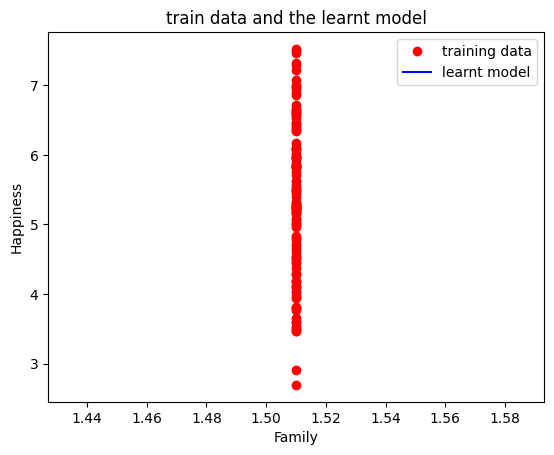

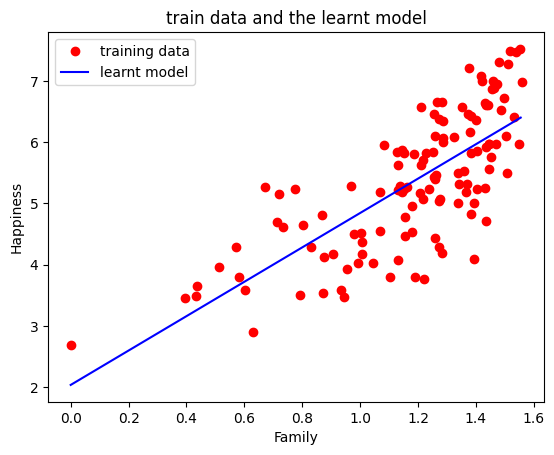

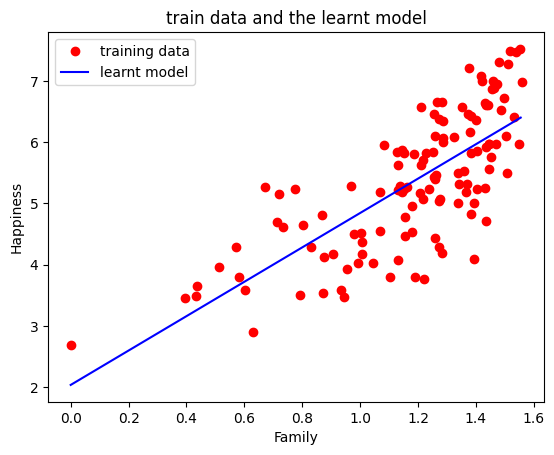

In [40]:
plotare_model(trainInputs1, trainOutputs1, w01, w11)
plotare_model(trainInputs2, trainOutputs2, w02, w12)
plotare_model(trainInputs3, trainOutputs3, w03, w13)

In [42]:
def predictii_model_family(regressor, validationInputs):
    computedValidationOutputs = regressor.predict(validationInputs)
    return computedValidationOutputs

computedValidationOutputs1 = predictii_model_family(regressor1, validationInputs1)
computedValidationOutputs2 = predictii_model_family(regressor2, validationInputs2)
computedValidationOutputs3 = predictii_model_family(regressor3, validationInputs3)

In [43]:
def plot_predictii_family(validationInputs, validationOutputs, computedValidationOutputs):
    plt.plot(validationInputs, computedValidationOutputs, 'yo', label='predicted data')
    plt.plot(validationInputs, validationOutputs, 'g^', label='real data')
    plt.title('predicted vs real validation data')
    plt.xlabel('Family')
    plt.ylabel('Happiness')
    plt.legend()
    plt.show()

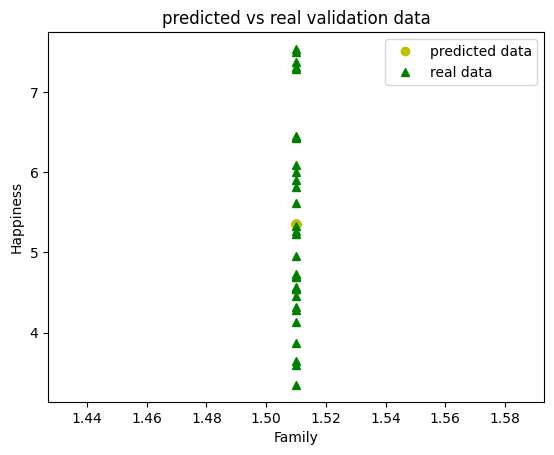

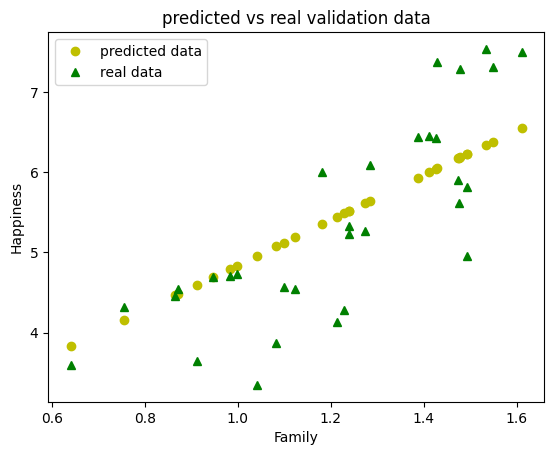

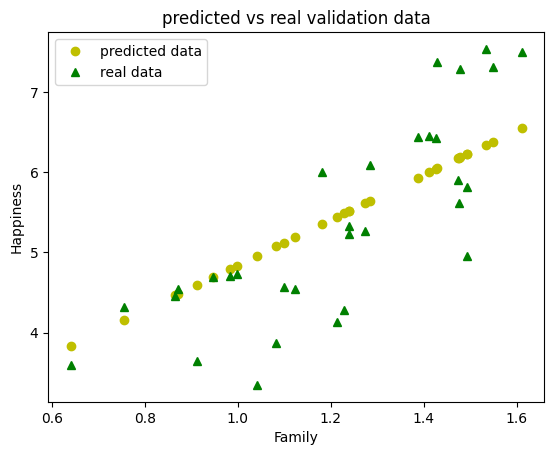

In [44]:
plot_predictii_family(validationInputs1, validationOutputs1, computedValidationOutputs1)
plot_predictii_family(validationInputs2, validationOutputs2, computedValidationOutputs2)
plot_predictii_family(validationInputs3, validationOutputs3, computedValidationOutputs3)

In [45]:
from sklearn.metrics import mean_squared_error, mean_absolute_error

def evaluare_model_family(validationOutputs, computedValidationOutputs):
    n = len(validationOutputs)

    # MSE manual
    mse_manual = 0.0
    for real, pred in zip(validationOutputs, computedValidationOutputs):
        mse_manual += (real - pred) ** 2
    mse_manual = mse_manual / n

    # MAE manual
    mae_manual = 0.0
    for real, pred in zip(validationOutputs, computedValidationOutputs):
        mae_manual += abs(real - pred)
    mae_manual = mae_manual / n

    # MSE cu tool
    mse_tool = mean_squared_error(validationOutputs, computedValidationOutputs)

    # MAE cu tool
    mae_tool = mean_absolute_error(validationOutputs, computedValidationOutputs)

    print("----- MSE -----")
    print("Manual:", mse_manual)
    print("Tool:  ", mse_tool)

    print("\n----- MAE -----")
    print("Manual:", mae_manual)
    print("Tool:  ", mae_tool)

    return mse_manual, mse_tool, mae_manual, mae_tool

In [46]:
print("Evaluare v1")
evaluare_model_family(validationOutputs1, computedValidationOutputs1)

print("\nEvaluare v2")
evaluare_model_family(validationOutputs2, computedValidationOutputs2)

print("\nEvaluare v3")
evaluare_model_family(validationOutputs3, computedValidationOutputs3)

Evaluare v1
----- MSE -----
Manual: 1.488969965516146
Tool:   1.488969965516146

----- MAE -----
Manual: 1.041084771705255
Tool:   1.041084771705255

Evaluare v2
----- MSE -----
Manual: 0.6051231125473586
Tool:   0.6051231125473586

----- MAE -----
Manual: 0.6262605660371903
Tool:   0.6262605660371905

Evaluare v3
----- MSE -----
Manual: 0.6051231125473586
Tool:   0.6051231125473586

----- MAE -----
Manual: 0.6262605660371903
Tool:   0.6262605660371905


(0.6051231125473586,
 0.6051231125473586,
 0.6262605660371903,
 0.6262605660371905)

# PROBLEMA 2 - PENTRU GDP SI FREEDOM

In [47]:
def incarcare_date_github_3d(github_raw_url, inputVariabName1, inputVariabName2, outputVariabName):
    response = urllib.request.urlopen(github_raw_url)
    lines = [line.decode('utf-8') for line in response.readlines()]

    data = []
    dataNames = []
    csv_reader = csv.reader(lines, delimiter=',')

    for i, row in enumerate(csv_reader):
        if i == 0:
            dataNames = row
        else:
            data.append(row)

    gdp_idx = dataNames.index(inputVariabName1)
    freedom_idx = dataNames.index(inputVariabName2)
    happiness_idx = dataNames.index(outputVariabName)

    inputs = []
    outputs = []
    gdp_values = []
    freedom_values = []
    happiness_values = []
    invalid_rows = 0

    for row in data:
        try:
            gdp = float(row[gdp_idx])
            freedom = float(row[freedom_idx])
            happiness = float(row[happiness_idx])

            if gdp > 0 and freedom > 0 and happiness > 0:
                inputs.append([gdp, freedom])
                outputs.append(happiness)
                gdp_values.append(gdp)
                freedom_values.append(freedom)
                happiness_values.append(happiness)
            else:
                invalid_rows += 1
        except (ValueError, IndexError):
            invalid_rows += 1

    print("\nStatistici încărcare:")
    print(f"- Rânduri totale: {len(data)}")
    print(f"- Rânduri valide: {len(inputs)}")
    print(f"- Rânduri filtrate: {invalid_rows}")

    return inputs, outputs, gdp_values, freedom_values, happiness_values

In [49]:
inputs1, outputs1, gdp1, freedom1, happiness1 = incarcare_date_github_3d(
    github_raw_url1,
    'Economy..GDP.per.Capita.',
    'Freedom',
    'Happiness.Score'
)

inputs2, outputs2, gdp2, freedom2, happiness2 = incarcare_date_github_3d(
    github_raw_url2,
    'Economy..GDP.per.Capita.',
    'Freedom',
    'Happiness.Score'
)

inputs3, outputs3, gdp3, freedom3, happiness3 = incarcare_date_github_3d(
    github_raw_url3,
    'Economy..GDP.per.Capita.',
    'Freedom',
    'Happiness.Score'
)


Statistici încărcare:
- Rânduri totale: 155
- Rânduri valide: 153
- Rânduri filtrate: 2

Statistici încărcare:
- Rânduri totale: 155
- Rânduri valide: 154
- Rânduri filtrate: 1

Statistici încărcare:
- Rânduri totale: 155
- Rânduri valide: 147
- Rânduri filtrate: 8


In [50]:
def histograma_3d(data, title, xlabel, color='skyblue'):
    plt.figure(figsize=(8, 5))
    plt.hist(data, color=color, alpha=0.7)
    plt.title(f'Distribuția {title}', fontsize=14)
    plt.xlabel(xlabel, fontsize=12)
    plt.ylabel('Frecvență', fontsize=12)
    plt.grid(axis='y', alpha=0.3)
    plt.show()

v1


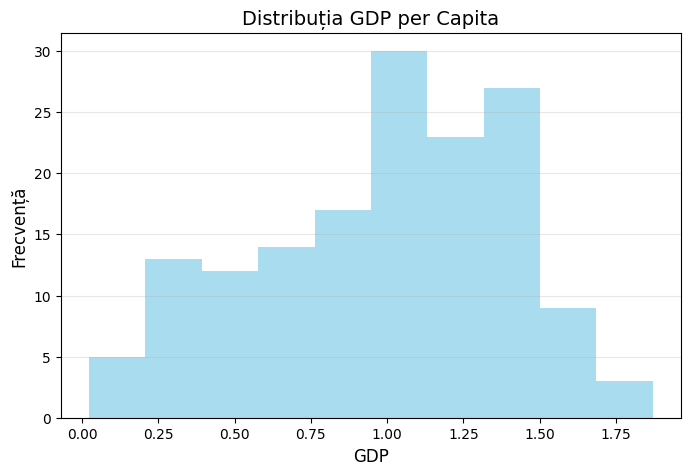

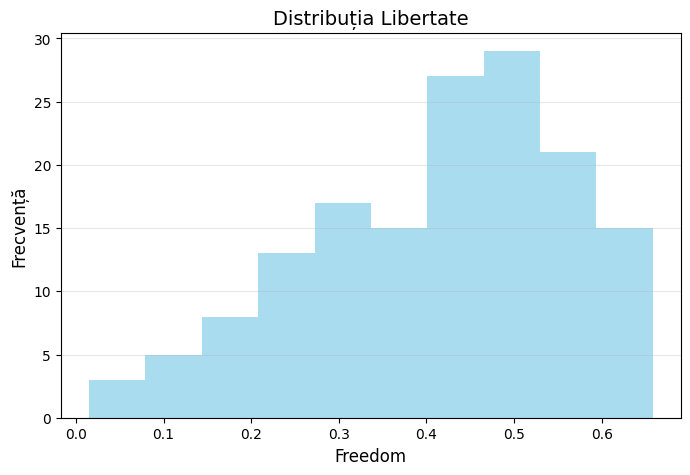

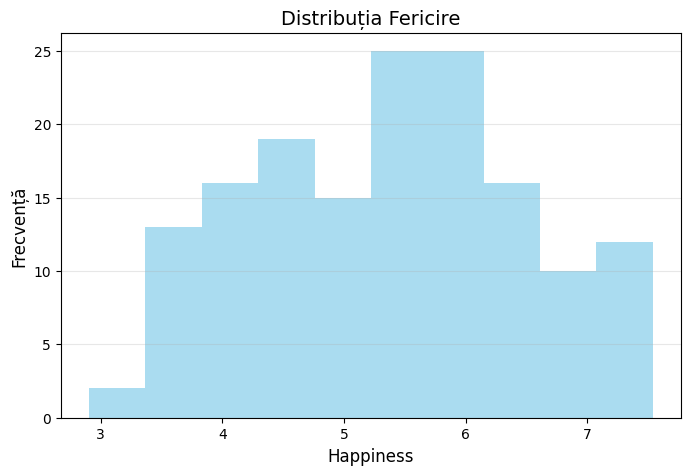

v2


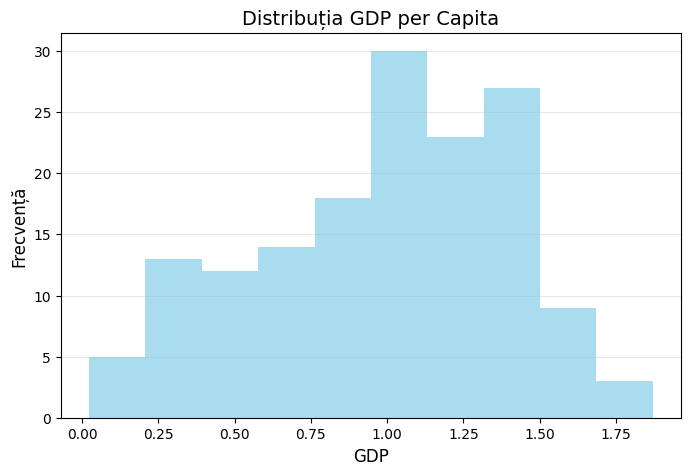

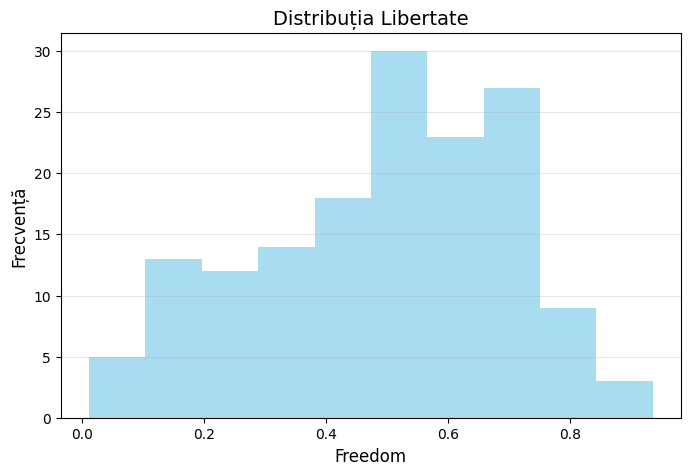

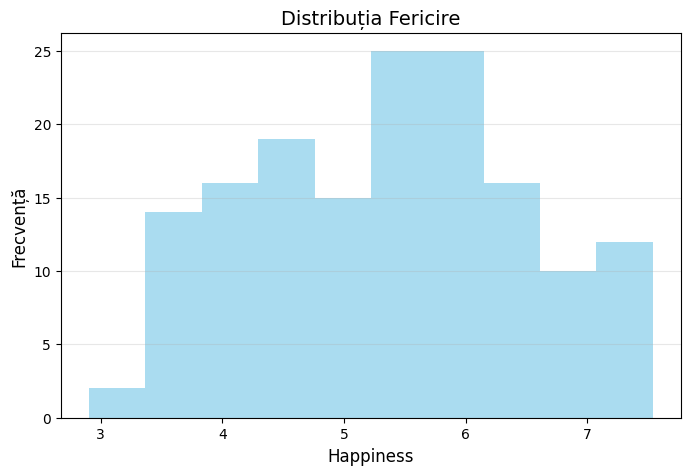

v3


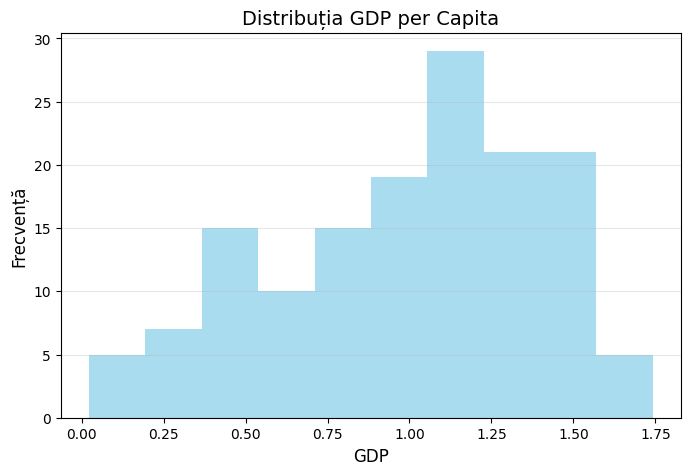

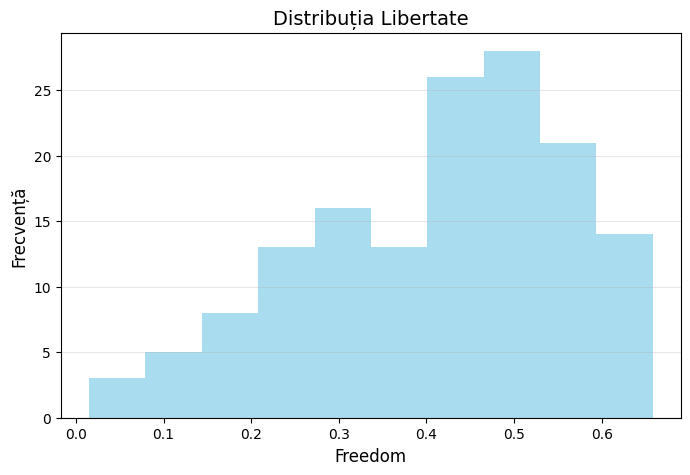

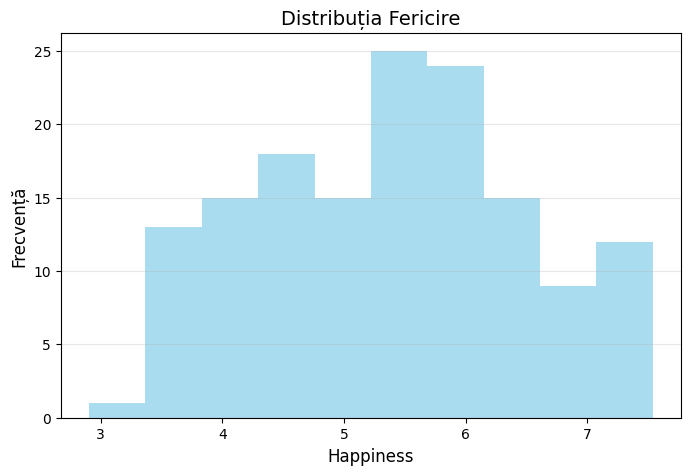

In [51]:
print("v1")
histograma_3d(gdp1, 'GDP per Capita', 'GDP')
histograma_3d(freedom1, 'Libertate', 'Freedom')
histograma_3d(happiness1, 'Fericire', 'Happiness')

print("v2")
histograma_3d(gdp2, 'GDP per Capita', 'GDP')
histograma_3d(freedom2, 'Libertate', 'Freedom')
histograma_3d(happiness2, 'Fericire', 'Happiness')

print("v3")
histograma_3d(gdp3, 'GDP per Capita', 'GDP')
histograma_3d(freedom3, 'Libertate', 'Freedom')
histograma_3d(happiness3, 'Fericire', 'Happiness')

In [52]:
def verificare_liniaritate_3d(inputs, outputs, figsize=(14, 10)):
    gdp = [x[0] for x in inputs]
    freedom = [x[1] for x in inputs]
    happiness = outputs

    fig = plt.figure(figsize=figsize)
    ax = fig.add_subplot(111, projection='3d')

    ax.scatter(gdp, freedom, happiness, s=80)

    ax.set_xlabel('GDP per Capita', fontsize=12)
    ax.set_ylabel('Freedom Score', fontsize=12)
    ax.set_zlabel('Happiness Score', fontsize=12)

    plt.title('Relația dintre GDP, Freedom și Happiness', fontsize=14, pad=20)
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

v1


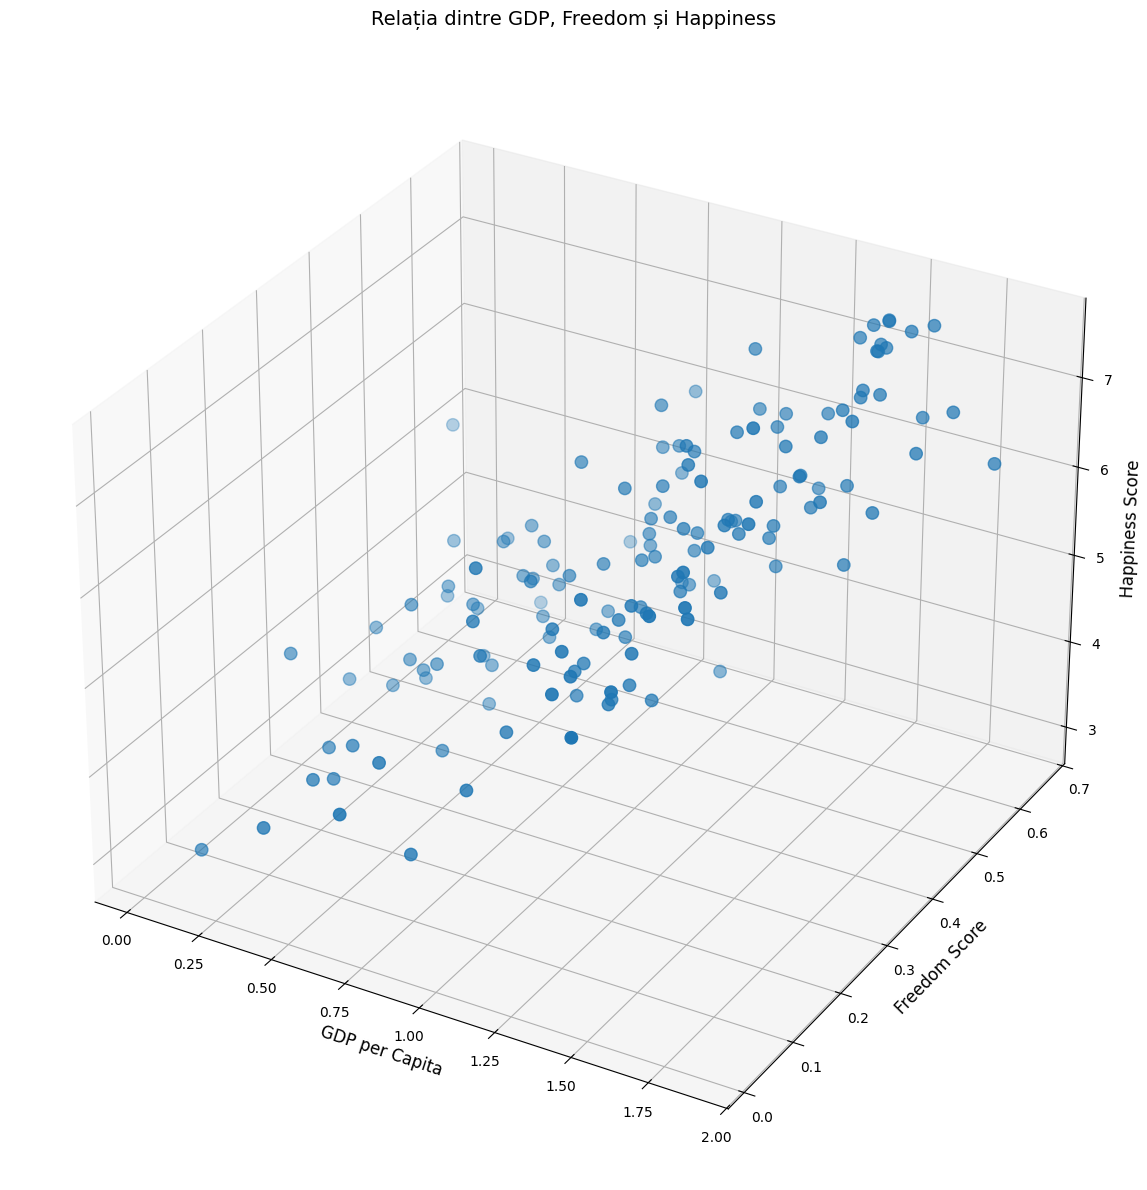

v2


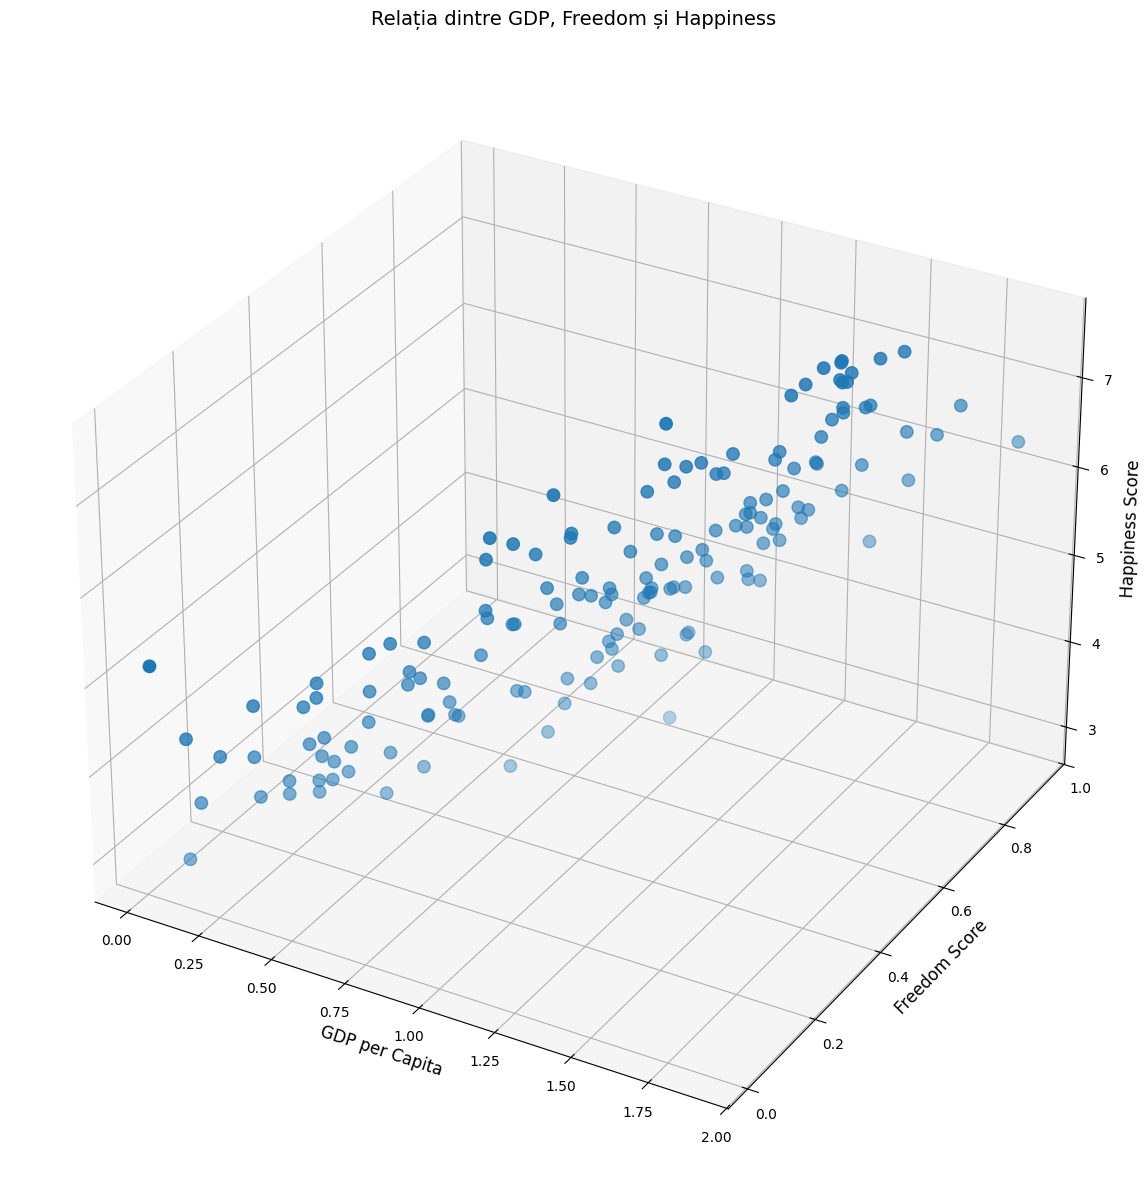

v3


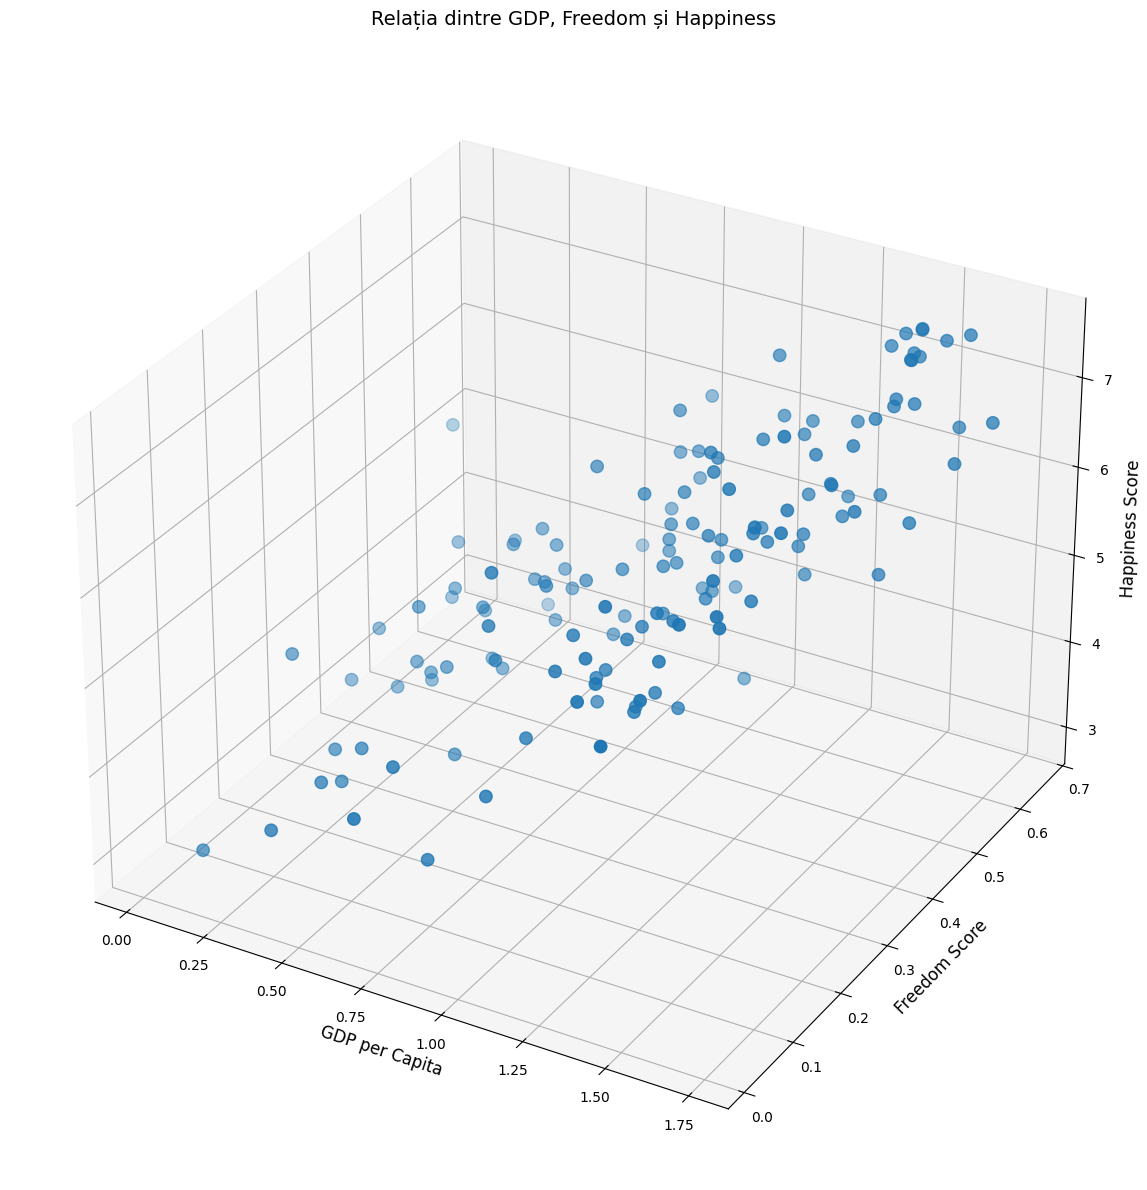

In [54]:
print("v1")
verificare_liniaritate_3d(inputs1, outputs1, figsize=(16, 12))

print("v2")
verificare_liniaritate_3d(inputs2, outputs2, figsize=(16, 12))

print("v3")
verificare_liniaritate_3d(inputs3, outputs3, figsize=(16, 12))

In [55]:
def divizare_date_3d(inputs, outputs):
    np.random.seed(5)
    indexes = np.arange(len(inputs))
    trainSample = np.random.choice(indexes, int(0.8 * len(inputs)), replace=False)
    validationSample = np.setdiff1d(indexes, trainSample)

    trainGDP = [inputs[i][0] for i in trainSample]
    trainFreedom = [inputs[i][1] for i in trainSample]
    trainOutputs = [outputs[i] for i in trainSample]

    valGDP = [inputs[i][0] for i in validationSample]
    valFreedom = [inputs[i][1] for i in validationSample]
    valOutputs = [outputs[i] for i in validationSample]

    fig = plt.figure(figsize=(14, 10))
    ax = fig.add_subplot(111, projection='3d')

    ax.scatter(trainGDP, trainFreedom, trainOutputs,
               c='blue', marker='o', s=40, alpha=0.7, label='Antrenare')

    ax.scatter(valGDP, valFreedom, valOutputs,
               c='red', marker='^', s=40, alpha=0.7, label='Validare')

    ax.set_xlabel('GDP per Capita')
    ax.set_ylabel('Freedom Score')
    ax.set_zlabel('Happiness Score')
    ax.set_title('Împărțirea datelor în Antrenare/Validare (3D)')
    ax.legend()
    ax.grid(True, alpha=0.3)
    ax.view_init(elev=25, azim=45)

    plt.tight_layout()
    plt.show()

    print("Statistici împărțire:")
    print(f"- Total instanțe: {len(inputs)}")
    print(f"- Antrenare: {len(trainSample)} ({len(trainSample)/len(inputs):.1%})")
    print(f"- Validare: {len(validationSample)} ({len(validationSample)/len(inputs):.1%})")

    return trainGDP, trainFreedom, trainOutputs, valGDP, valFreedom, valOutputs

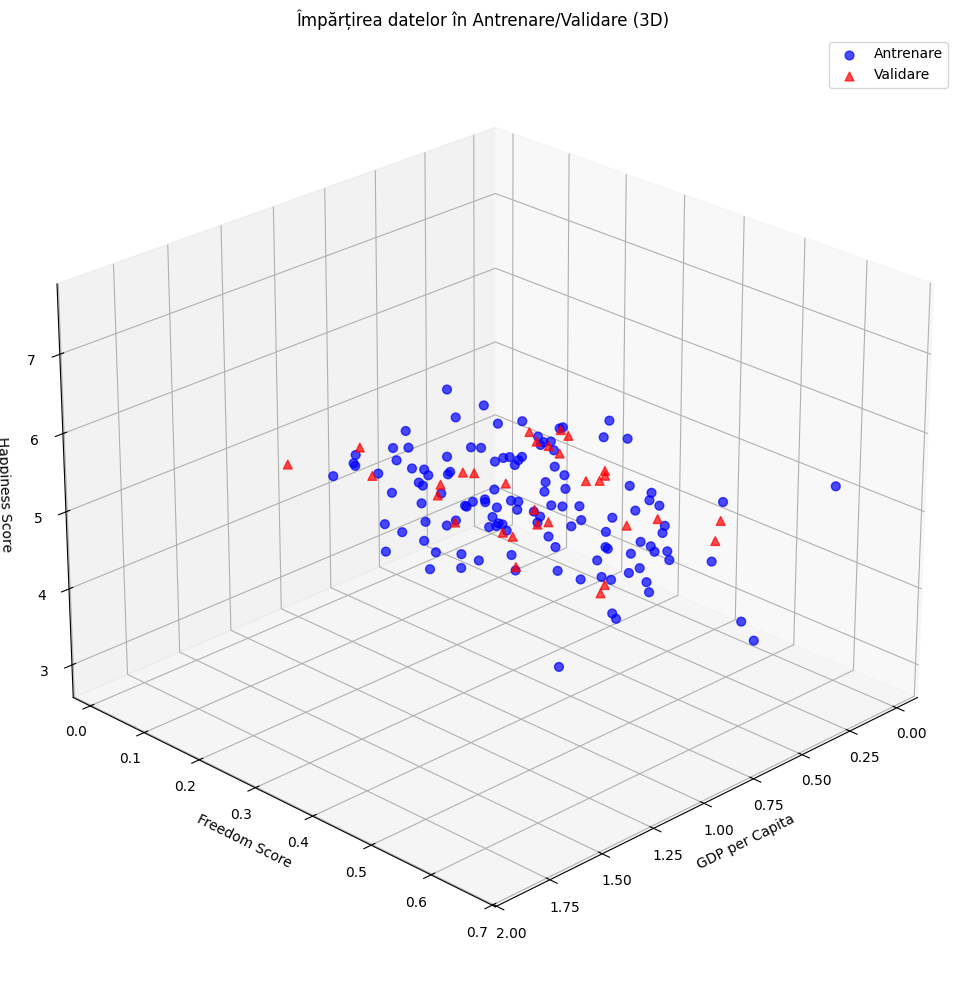

Statistici împărțire:
- Total instanțe: 153
- Antrenare: 122 (79.7%)
- Validare: 31 (20.3%)


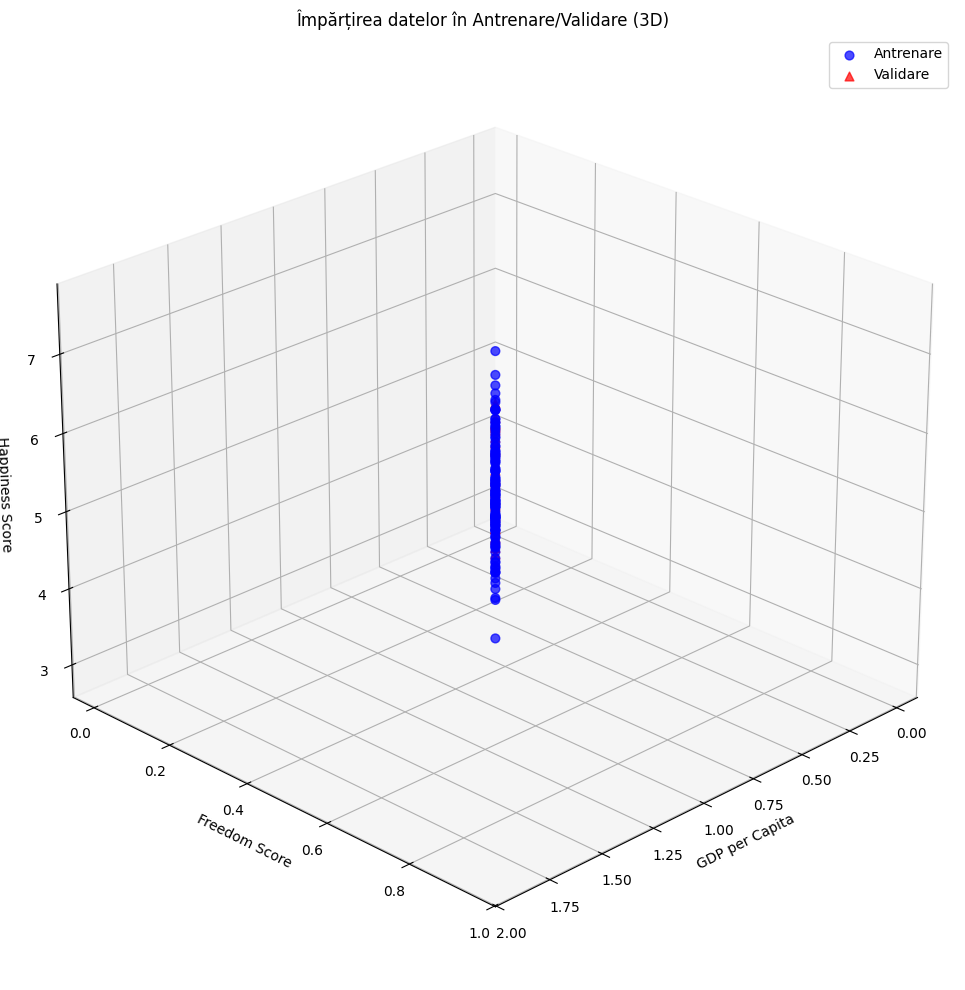

Statistici împărțire:
- Total instanțe: 154
- Antrenare: 123 (79.9%)
- Validare: 31 (20.1%)


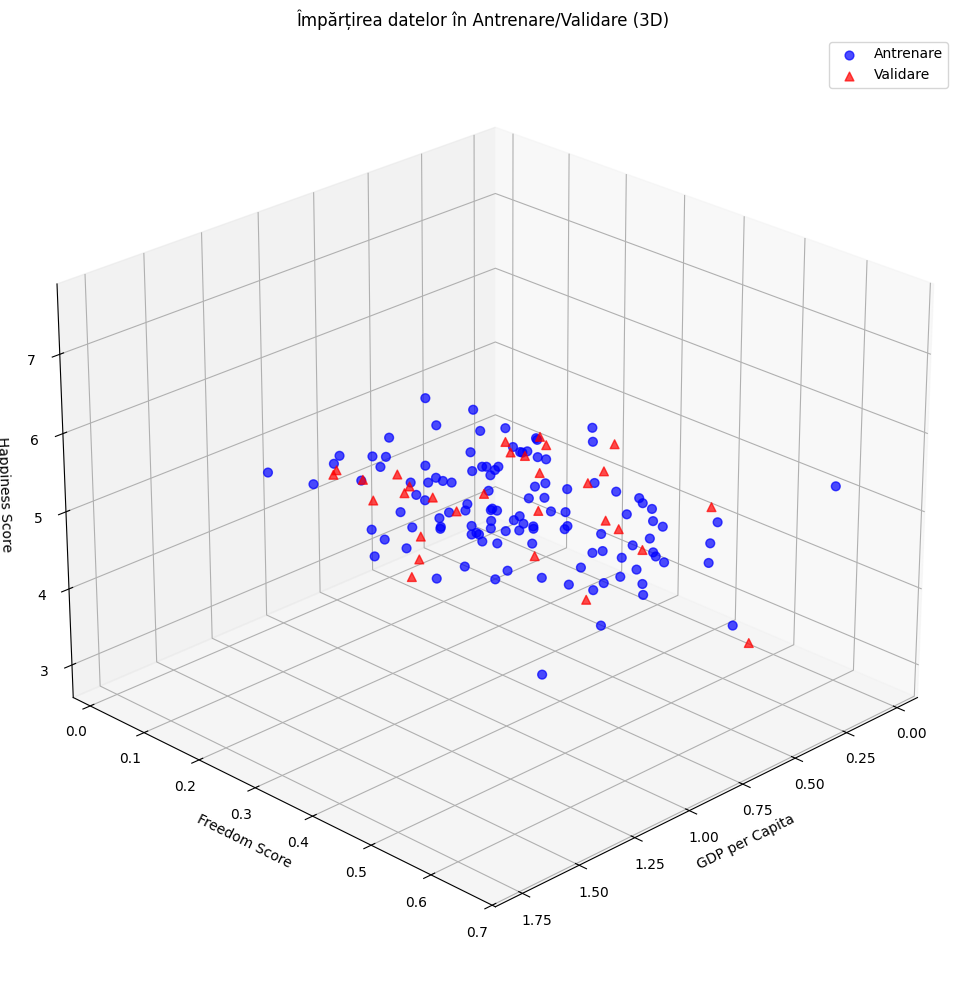

Statistici împărțire:
- Total instanțe: 147
- Antrenare: 117 (79.6%)
- Validare: 30 (20.4%)


In [56]:
trainGDP1, trainFreedom1, trainOutputs1, valGDP1, valFreedom1, valOutputs1 = divizare_date_3d(inputs1, outputs1)

trainGDP2, trainFreedom2, trainOutputs2, valGDP2, valFreedom2, valOutputs2 = divizare_date_3d(inputs2, outputs2)

trainGDP3, trainFreedom3, trainOutputs3, valGDP3, valFreedom3, valOutputs3 = divizare_date_3d(inputs3, outputs3)

In [58]:
def antrenare_model_3d(trainGDP, trainFreedom, trainOutputs):
    min_len = min(len(trainGDP), len(trainFreedom), len(trainOutputs))

    trainGDP = trainGDP[:min_len]
    trainFreedom = trainFreedom[:min_len]
    trainOutputs = trainOutputs[:min_len]

    X_train = np.column_stack((trainGDP, trainFreedom))
    y_train = np.array(trainOutputs)

    regressor = Codul_meu_pentru_regresie_multipla()
    regressor.fit(X_train, y_train)

    print(f"the learnt model f(x) = {regressor.intercept_:.4f} + {regressor.coef_[0]}*x1 + {regressor.coef_[1]}*x2")

    return X_train, y_train, regressor

In [59]:
X_train1, y_train1, regressor1 = antrenare_model_3d(trainGDP1, trainFreedom1, trainOutputs1)
X_train2, y_train2, regressor2 = antrenare_model_3d(trainGDP2, trainFreedom2, trainOutputs2)
X_train3, y_train3, regressor3 = antrenare_model_3d(trainGDP3, trainFreedom3, trainOutputs3)

the learnt model f(x) = 2.5734 + 1.8838383621169517*x1 + 2.1945991815046715*x2
the learnt model f(x) = 3.2723 + 522911717.0749029*x1 + -1045823429.9721985*x2
the learnt model f(x) = 2.5506 + 1.875299056958391*x1 + 2.366830649434269*x2


In [60]:
def plotarea_regresiei_3d(X_train, y_train, regressor):
    w0 = regressor.intercept_
    w1, w2 = regressor.coef_

    gdp = X_train[:, 0]
    freedom = X_train[:, 1]

    gdp_range = np.linspace(min(gdp), max(gdp), 20)
    freedom_range = np.linspace(min(freedom), max(freedom), 20)
    gdp_grid, freedom_grid = np.meshgrid(gdp_range, freedom_range)

    happiness_grid = w0 + w1 * gdp_grid + w2 * freedom_grid

    fig = plt.figure(figsize=(14, 10))
    ax = fig.add_subplot(111, projection='3d')

    ax.plot_surface(gdp_grid, freedom_grid, happiness_grid, alpha=0.7)
    ax.scatter(gdp, freedom, y_train, c='red', s=40, alpha=1, label='Date observate')

    ax.set_xlabel('GDP per Capita')
    ax.set_ylabel('Freedom Score')
    ax.set_zlabel('Happiness Score')
    ax.set_title('Regresie liniară multiplă: GDP și Freedom vs Happiness')

    ax.view_init(elev=25, azim=45)
    ax.legend()
    plt.tight_layout()
    plt.show()

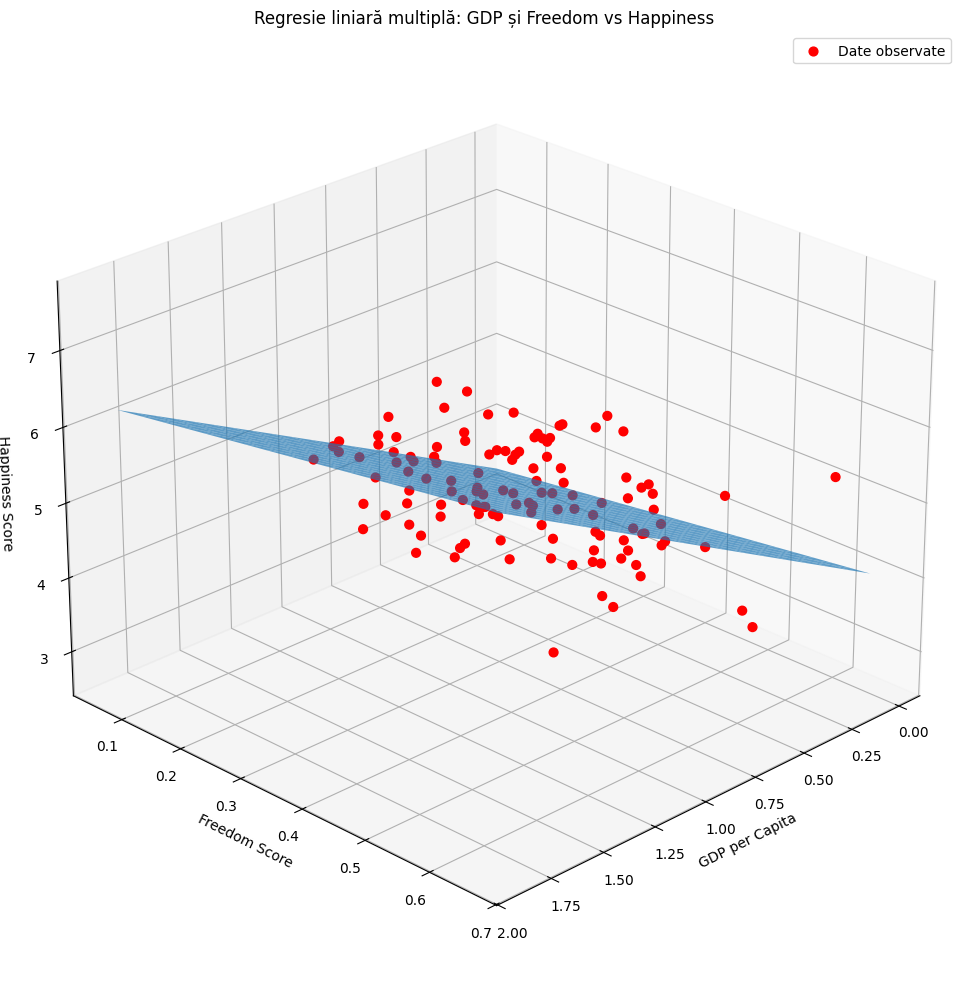

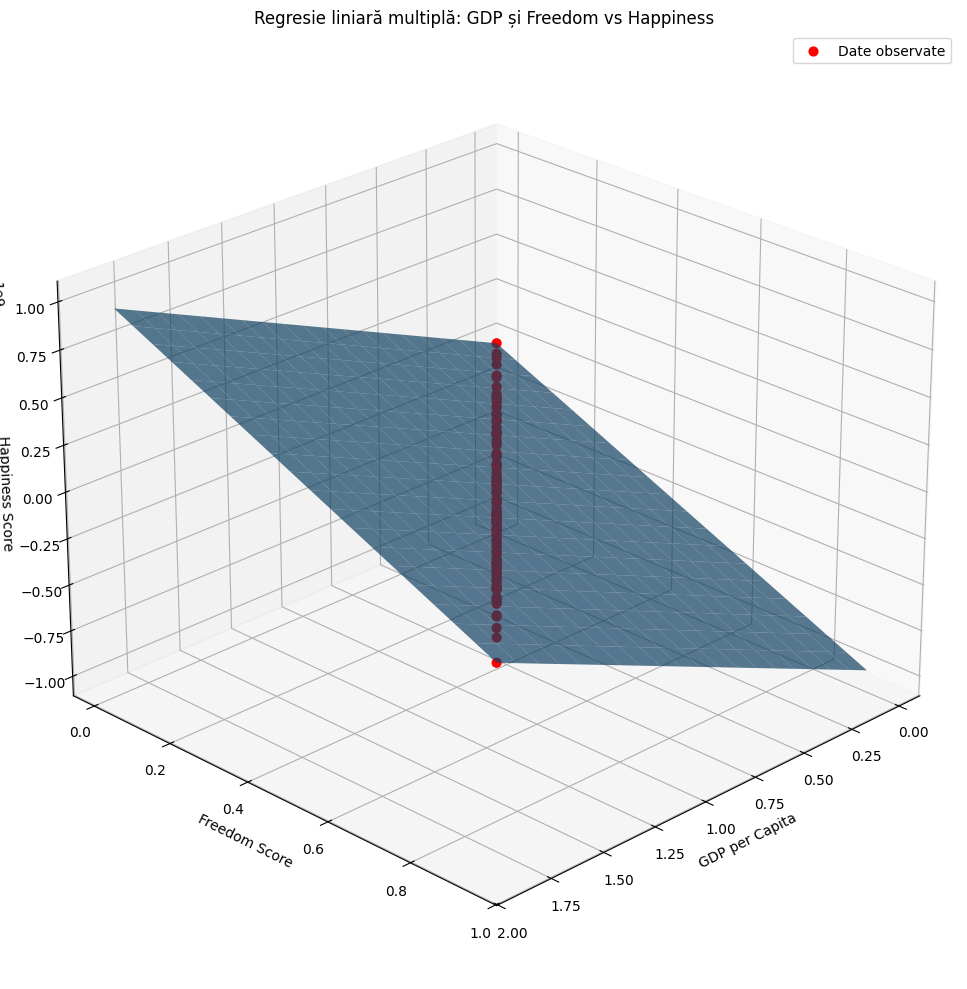

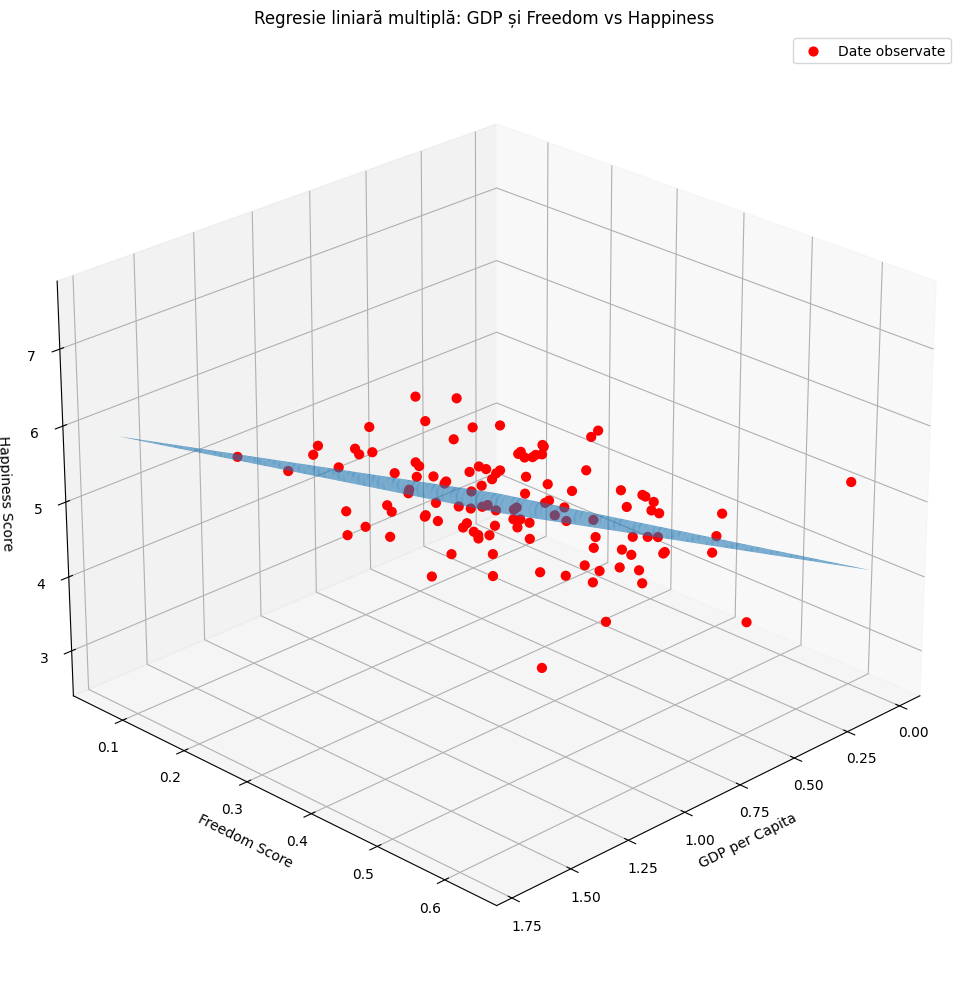

In [61]:
plotarea_regresiei_3d(X_train1, y_train1, regressor1)
plotarea_regresiei_3d(X_train2, y_train2, regressor2)
plotarea_regresiei_3d(X_train3, y_train3, regressor3)

In [62]:
def preziceri_3d(regressor, valGDP, valFreedom):
    validationInputs = np.column_stack((valGDP, valFreedom))
    computedValidationOutputs = regressor.predict(validationInputs)
    return validationInputs, computedValidationOutputs

In [64]:
validationInputs1, computedValidationOutputs1 = preziceri_3d(regressor1, valGDP1, valFreedom1)
validationInputs2, computedValidationOutputs2 = preziceri_3d(regressor2, valGDP2, valFreedom2)
validationInputs3, computedValidationOutputs3 = preziceri_3d(regressor3, valGDP3, valFreedom3)

In [65]:
def plotare_preziceri_3d(valGDP, valFreedom, valOutputs, computedValidationOutputs):
    validationOutputs = np.array(valOutputs)
    errors = validationOutputs - computedValidationOutputs
    mse = np.mean(errors ** 2)

    fig = plt.figure(figsize=(14, 10))
    ax = fig.add_subplot(111, projection='3d')

    ax.scatter(valGDP, valFreedom, validationOutputs,
               c='green', marker='^', s=50, label='Valori reale')

    ax.scatter(valGDP, valFreedom, computedValidationOutputs,
               c='blue', marker='o', s=50, label='Valori prezise')

    for gdp, freedom, real, pred in zip(valGDP, valFreedom, validationOutputs, computedValidationOutputs):
        ax.plot([gdp, gdp], [freedom, freedom], [real, pred], 'r--', alpha=0.3)

    ax.set_xlabel('GDP per Capita')
    ax.set_ylabel('Freedom Score')
    ax.set_zlabel('Happiness Score')
    ax.set_title(f'Comparație valori reale vs prezise\nMSE: {mse:.4f}')
    ax.legend()
    ax.view_init(elev=25, azim=45)
    plt.tight_layout()
    plt.show()

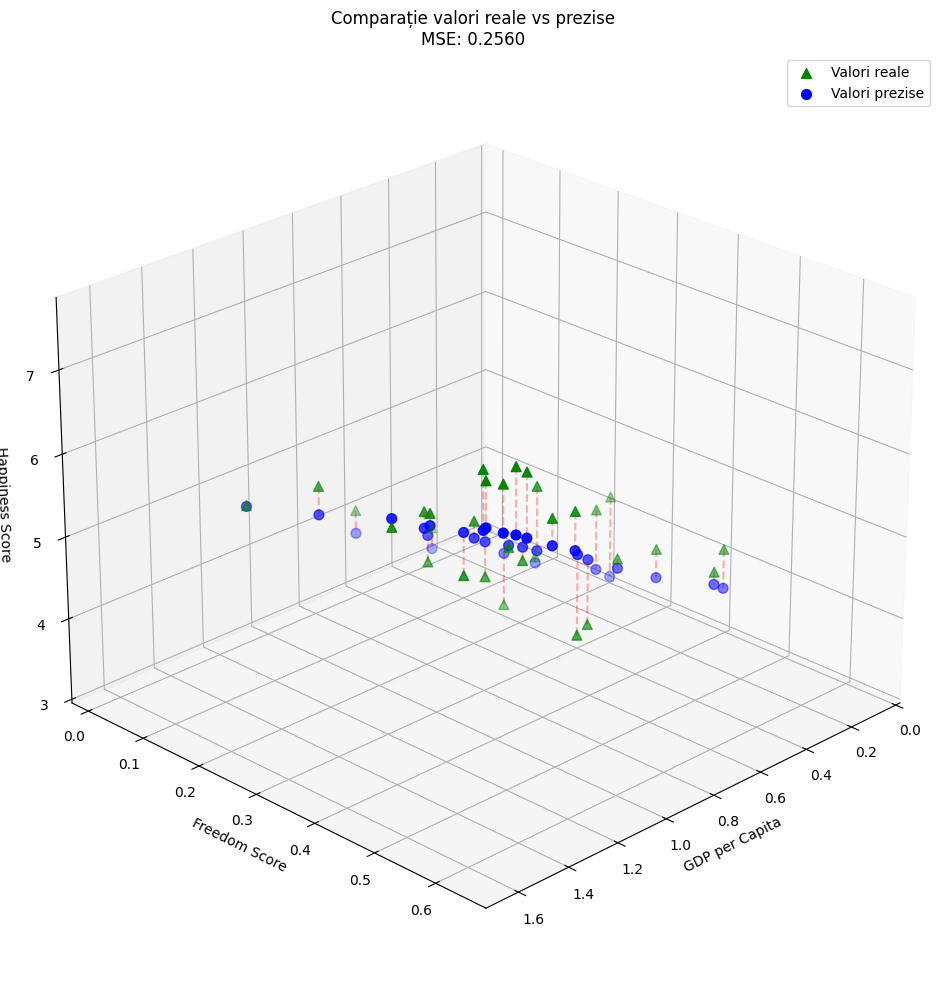

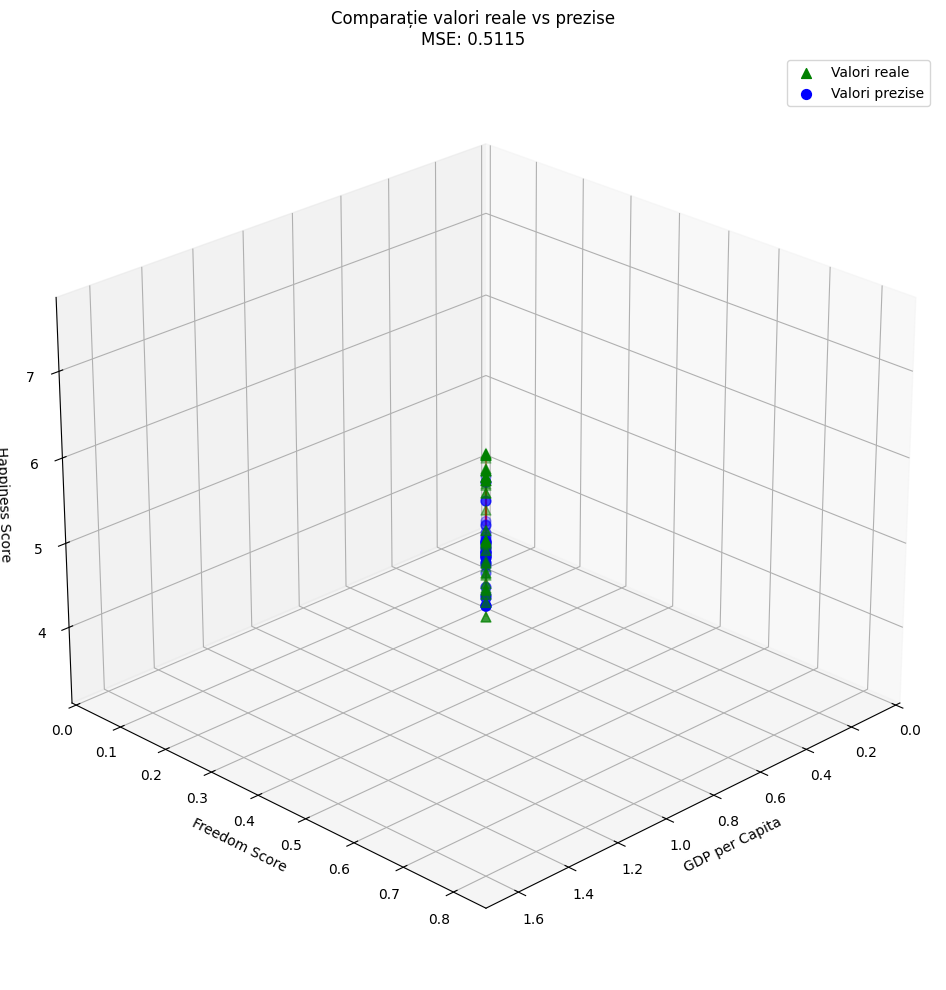

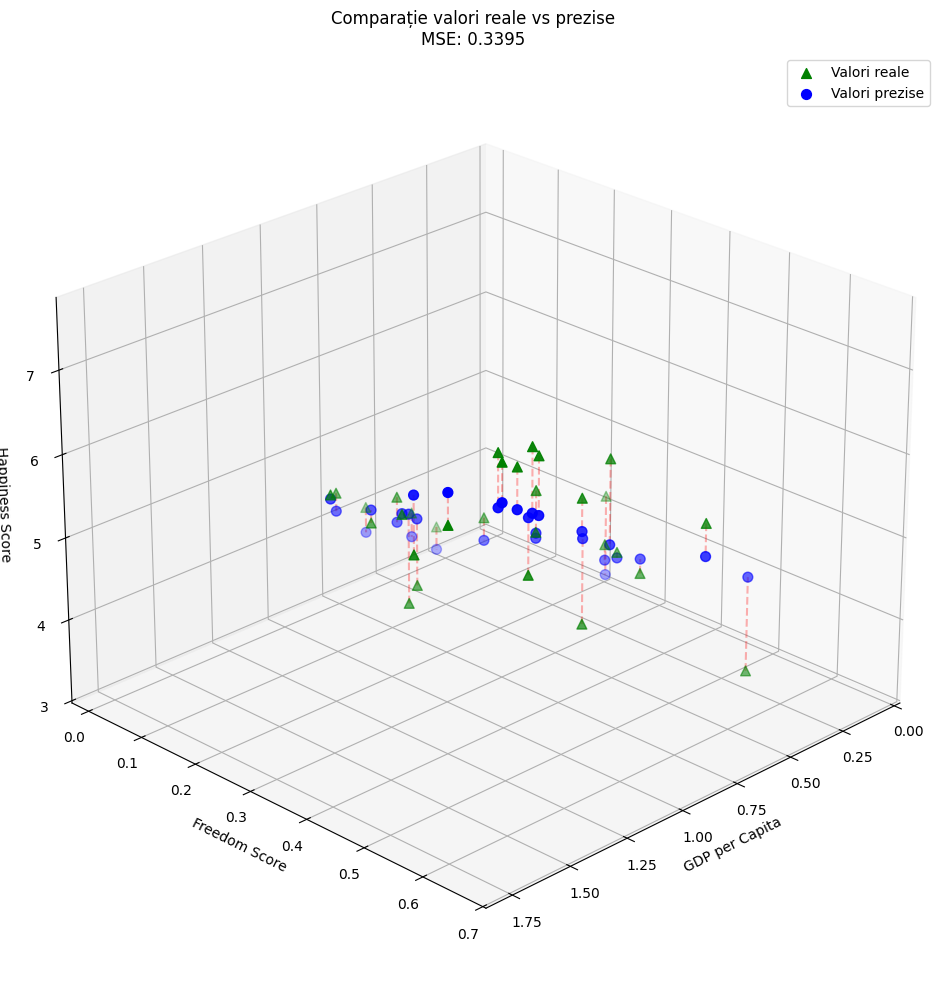

In [68]:
plotare_preziceri_3d(valGDP1, valFreedom1, valOutputs1, computedValidationOutputs1)
plotare_preziceri_3d(valGDP2, valFreedom2, valOutputs2, computedValidationOutputs2)
plotare_preziceri_3d(valGDP3, valFreedom3, valOutputs3, computedValidationOutputs3)

In [69]:
from sklearn.metrics import mean_squared_error, mean_absolute_error

def evaluare_model_3d(valOutputs, computedValidationOutputs):
    n = len(valOutputs)

    mse_manual = 0.0
    mae_manual = 0.0

    for real, pred in zip(valOutputs, computedValidationOutputs):
        mse_manual += (real - pred) ** 2
        mae_manual += abs(real - pred)

    mse_manual /= n
    mae_manual /= n

    mse_tool = mean_squared_error(valOutputs, computedValidationOutputs)
    mae_tool = mean_absolute_error(valOutputs, computedValidationOutputs)

    print("----- MSE -----")
    print("Manual:", mse_manual)
    print("Tool:  ", mse_tool)

    print("\n----- MAE -----")
    print("Manual:", mae_manual)
    print("Tool:  ", mae_tool)

    return mse_manual, mse_tool, mae_manual, mae_tool

In [70]:
print("Evaluare v1")
evaluare_model_3d(valOutputs1, computedValidationOutputs1)

print("\nEvaluare v2")
evaluare_model_3d(valOutputs2, computedValidationOutputs2)

print("\nEvaluare v3")
evaluare_model_3d(valOutputs3, computedValidationOutputs3)

Evaluare v1
----- MSE -----
Manual: 0.25596467938647066
Tool:   0.25596467938647066

----- MAE -----
Manual: 0.42231778849433793
Tool:   0.42231778849433793

Evaluare v2
----- MSE -----
Manual: 0.5115109288219254
Tool:   0.5115109288219254

----- MAE -----
Manual: 0.5865488068736499
Tool:   0.5865488068736499

Evaluare v3
----- MSE -----
Manual: 0.33952421009493483
Tool:   0.3395242100949349

----- MAE -----
Manual: 0.48124069162970523
Tool:   0.48124069162970534


(np.float64(0.33952421009493483),
 0.3395242100949349,
 np.float64(0.48124069162970523),
 0.48124069162970534)